<a href="https://colab.research.google.com/github/gadhyanchirag2004/Chirag-Gadhyan---EDA/blob/main/23BDS0265_Phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
# Import libraries
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform

In [3]:
#Loading the dataset
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/23BDS0265_CreditCard.csv')

Mounted at /content/drive


In [4]:
#Display first 10 rows
df.head(10)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
5,6,37,13,29,92121,4,0.4,2,155,0,0,0,1,0
6,7,53,27,72,91711,2,1.5,2,0,0,0,0,1,0
7,8,50,24,22,93943,1,0.3,3,0,0,0,0,0,1
8,9,35,10,81,90089,3,0.6,2,104,0,0,0,1,0
9,10,34,9,180,93023,1,8.9,3,0,1,0,0,0,0


In [5]:
#Display last 10 rows
df.tail(10)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
4990,4991,55,25,58,95023,4,2.00,3,219,0,0,0,0,1
4991,4992,51,25,92,91330,1,1.90,2,100,0,0,0,0,1
4992,4993,30,5,13,90037,4,0.50,3,0,0,0,0,0,0
4993,4994,45,21,218,91801,2,6.67,1,0,0,0,0,1,0
4994,4995,64,40,75,94588,3,2.00,3,0,0,0,0,1,0
4995,4996,29,3,40,92697,1,1.90,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.40,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.30,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.50,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.80,1,0,0,0,0,1,1


**Applying Basic Statistical Analysis**

In [6]:
#Shape
print("Shape of Dataset:", df.shape)

#Data types
print("\nData type of column")
print(df.dtypes)

#Dataset information
print("\nInformation about dataset")
print(df.info())

#Statistical analysis
print("\nStatistical analysis of dataset")
print(df.describe())

Shape of Dataset: (5000, 14)

Data type of column
ID                      int64
Age                     int64
Experience              int64
Income                  int64
ZIP Code                int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage                int64
Personal Loan          object
Securities Account     object
CD Account             object
Online                  int64
CreditCard             object
dtype: object

Information about dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null 

**Handling Missing Values & Data Cleaning**

In [7]:
df.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIP Code,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal Loan,0


In [8]:
df.isna().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIP Code,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal Loan,0


In [9]:
for col in df.columns:
    print(col)
    print(df[col].unique())

ID
[   1    2    3 ... 4998 4999 5000]
Age
[25 45 39 35 37 53 50 34 65 29 48 59 67 60 38 42 46 55 56 57 44 36 43 40
 30 31 51 32 61 41 28 49 47 62 58 54 33 27 66 24 52 26 64 63 23]
Experience
[ 1 19 15  9  8 13 27 24 10 39  5 23 32 41 30 14 18 21 28 31 11 16 20 35
  6 25  7 12 26 37 17  2 36 29  3 22 -1 34  0 38 40 33  4 -2 42 -3 43]
Income
[ 49  34  11 100  45  29  72  22  81 180 105 114  40 112 130 193  21  25
  63  62  43 152  83 158  48 119  35  41  18  50 121  71 141  80  84  60
 132 104  52 194   8 131 190  44 139  93 188  39 125  32  20 115  69  85
 135  12 133  19  82 109  42  78  51 113 118  64 161  94  15  74  30  38
   9  92  61  73  70 149  98 128  31  58  54 124 163  24  79 134  23  13
 138 171 168  65  10 148 159 169 144 165  59  68  91 172  55 155  53  89
  28  75 170 120  99 111  33 129 122 150 195 110 101 191 140 153 173 174
  90 179 145 200 183 182  88 160 205 164  14 175 103 108 185 204 154 102
 192 202 162 142  95 184 181 143 123 178 198 201 203 189 151 199 224 218]

In [10]:
# From the above cell it is found that there are missing values in the form of '?' in columns Personal Loan, Securities Account, CD Account,CreditCard
# We will try handle these missing values by replacing them or dropping them

df.replace("?", np.nan, inplace=True)
df.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIP Code,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal Loan,11


In [11]:
#Now can see the total no. of missing values in the dataset is 15.
#We will now replace these with some justifiable values. We can use mode() to replace these values as they appear to be categorical
for col in ['Personal Loan', 'Securities Account', 'CD Account', 'CreditCard']:
    df[col] = df[col].fillna(df[col].mode()[0])


In [12]:
# Now we will convert them into integers type
for col in ['Personal Loan', 'Securities Account', 'CD Account', 'CreditCard']:
  df[col] = df[col].astype(int)
df.dtypes

,0
ID,int64
Age,int64
Experience,int64
Income,int64
ZIP Code,int64
Family,int64
CCAvg,float64
Education,int64
Mortgage,int64
Personal Loan,int64


In [13]:
#Checking for duplicate records
print("Duplicate Rows:", df.duplicated())

Duplicate Rows: 0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool


There are no duplicate rows in the dataset.

Now we will be detecting outlier using box plot and IQR.

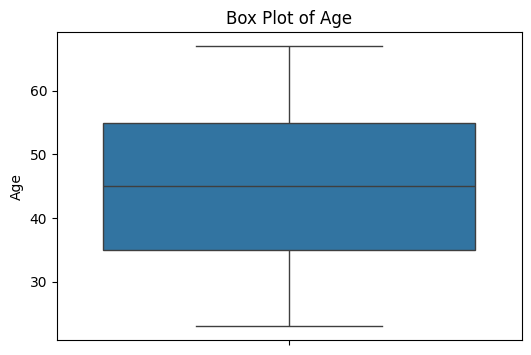

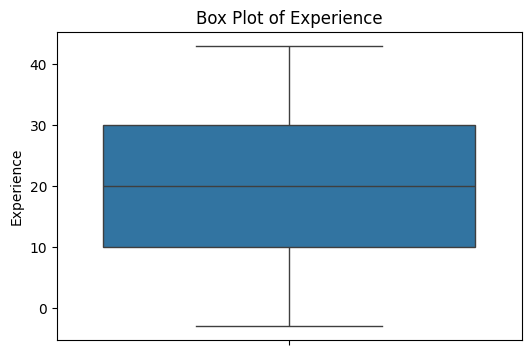

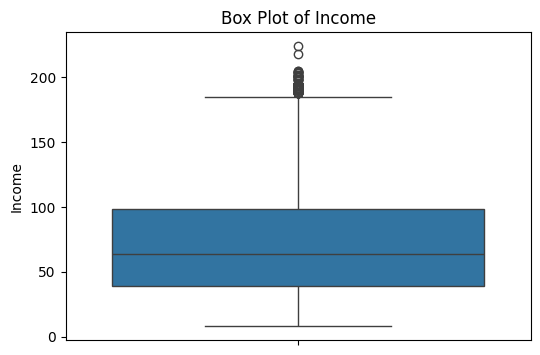

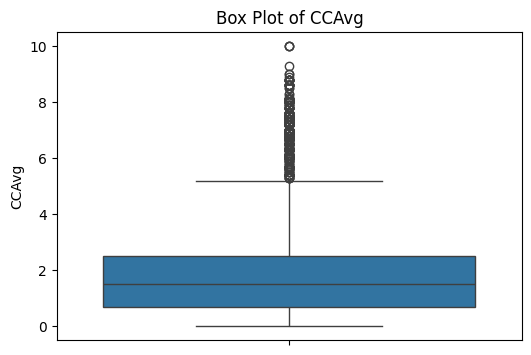

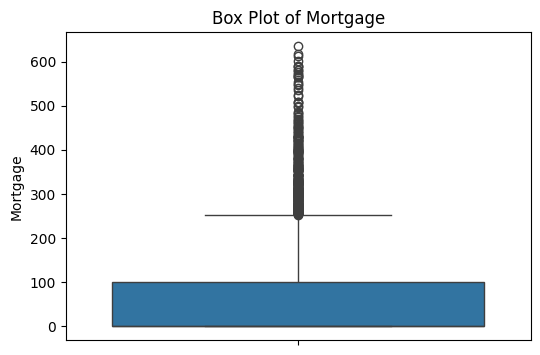

In [14]:
#Finding outliers using box plot
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()


In [15]:
numerical_cols = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']
print("Outlier Detection using IQR Method")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

Outlier Detection using IQR Method
Age: 0 outliers
Experience: 0 outliers
Income: 96 outliers
CCAvg: 324 outliers
Mortgage: 291 outliers


We find that there are outlier in Income, CCAvg, Mortgage variable but not in Age and Experience variables. We wont be removing outliers from the above attributes because some people can have higher incomes, higher credit card average and mortgage. Removing them might lead to loss of useful information. Therefore we will retain the values.


**#Data Transformation**

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])
df_scaled.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,-1.774417,-1.666078,-0.538229,91107,4,-0.193385,1,-0.555524,0,1,0,0,0
1,2,-0.029524,-0.096330,-0.864109,90089,3,-0.250611,1,-0.555524,0,1,0,0,0
2,3,-0.552992,-0.445163,-1.363793,94720,1,-0.536736,1,-0.555524,0,0,0,0,0
3,4,-0.901970,-0.968413,0.569765,94112,1,0.436091,2,-0.555524,0,0,0,0,0
4,5,-0.901970,-1.055621,-0.625130,91330,4,-0.536736,2,-0.555524,0,0,0,0,1


The numerical features like Age, Experience, Income, CCAvg, and Mortgage were standardized using StandardScaler. This transformation converts each feature to have a mean of 0 and a standard deviation of 1 which ensures that variables with larger numerical ranges do not dominate those with smaller ranges.

#Univariate Analysis

In [17]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


In [18]:
numerical_cols = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']
summary = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Mode': df[numerical_cols].mode().iloc[0],
    'Variance': df[numerical_cols].var(),
    'Standard Deviation': df[numerical_cols].std(),
})
summary

,Mean,Median,Mode,Variance,Standard Deviation
Age,45.338400,45.0,35.0,131.404166,11.463166
Experience,20.104600,20.0,32.0,131.513962,11.467954
Income,73.774200,64.0,44.0,2119.104235,46.033729
CCAvg,1.937938,1.5,0.3,3.054312,1.747659
Mortgage,56.498800,0.0,0.0,10345.697538,101.713802


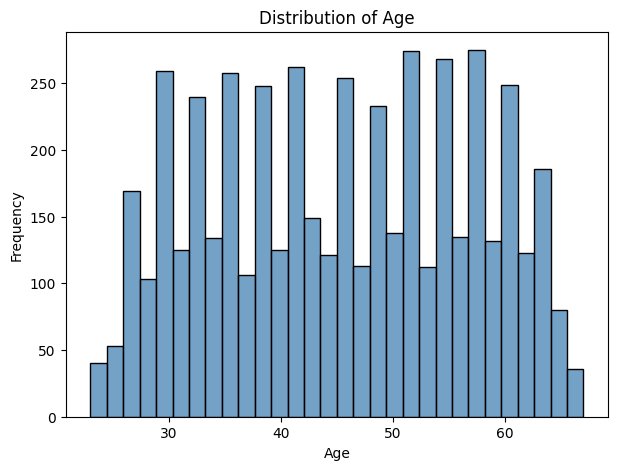

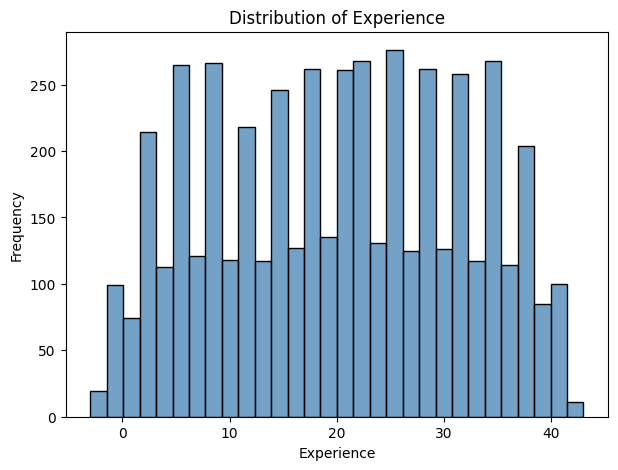

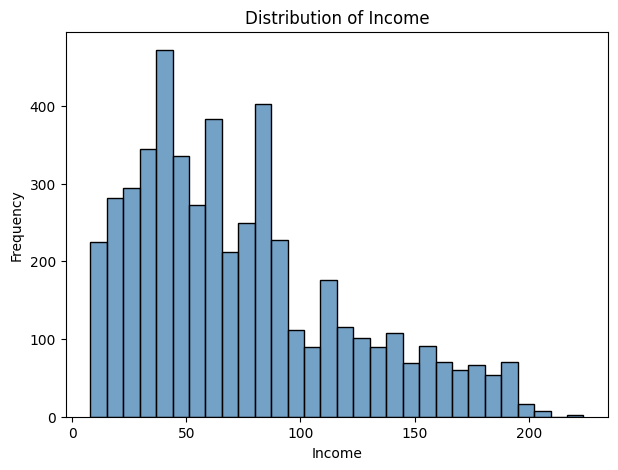

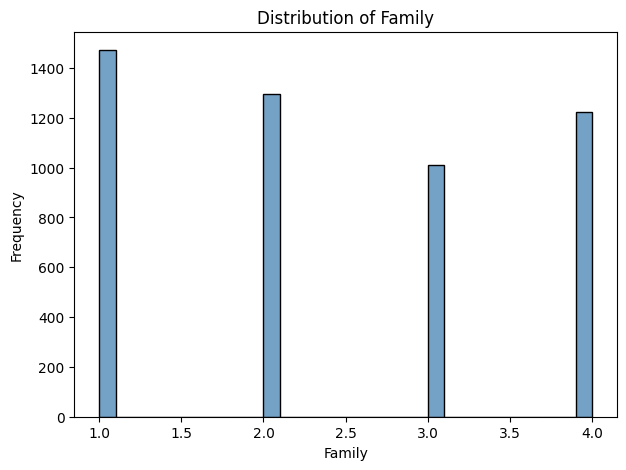

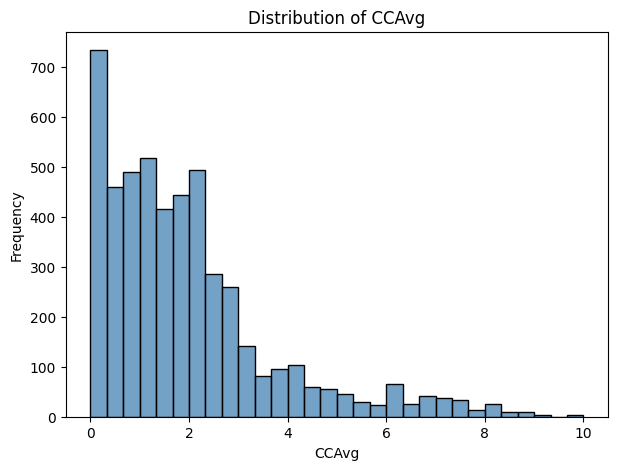

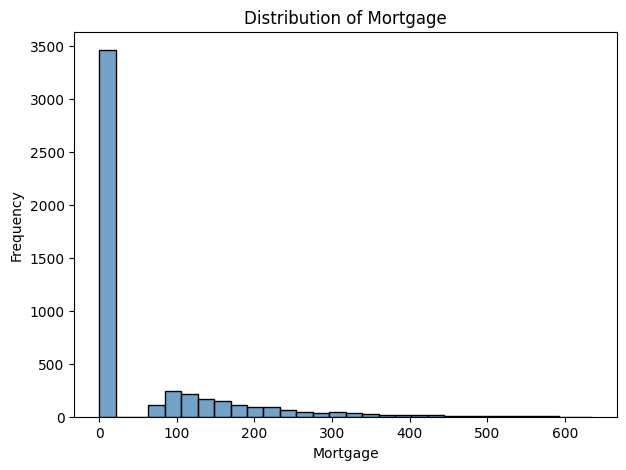

In [19]:
#Histogram
numerical_cols = ['Age', 'Experience', 'Income',
                  'Family', 'CCAvg', 'Mortgage']
for col in numerical_cols:
    plt.figure(figsize=(7,5))
    sns.histplot(df[col],
                 bins=30,
                 color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

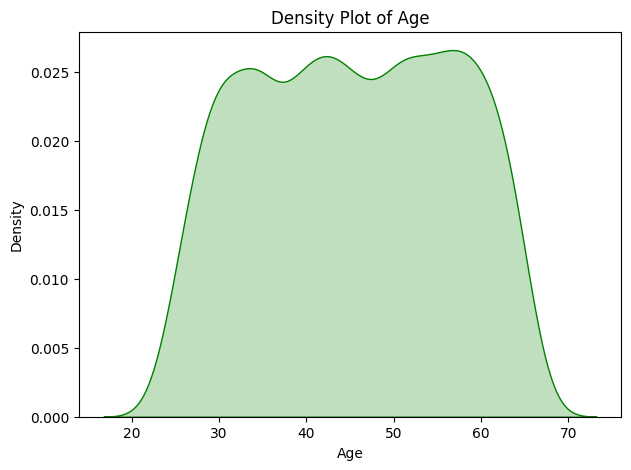

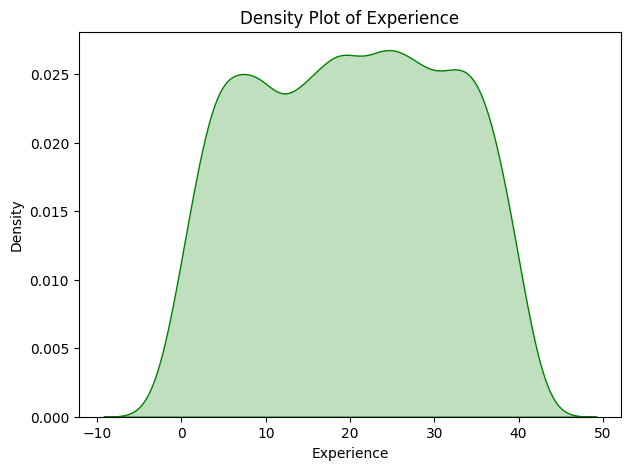

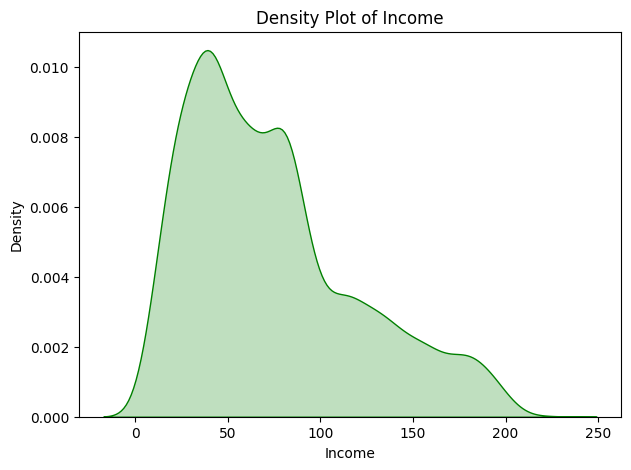

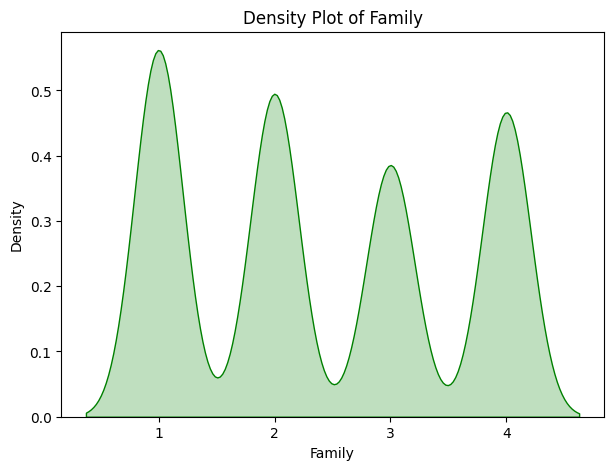

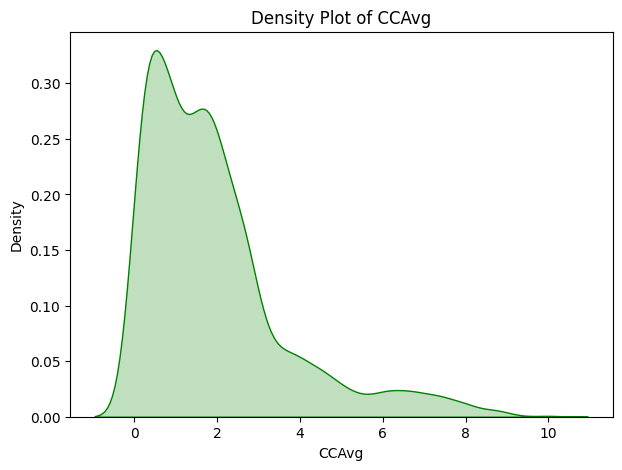

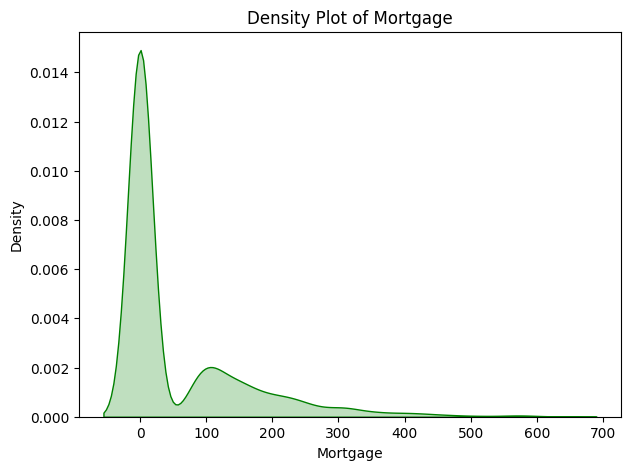

In [20]:
#Distribution Plot
for col in numerical_cols:
    plt.figure(figsize=(7,5))
    sns.kdeplot(df[col],
                fill=True,
                color='green')
    plt.title(f'Density Plot of {col}')
    plt.show()

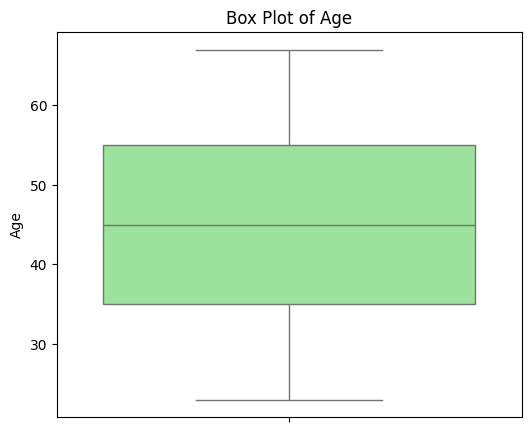

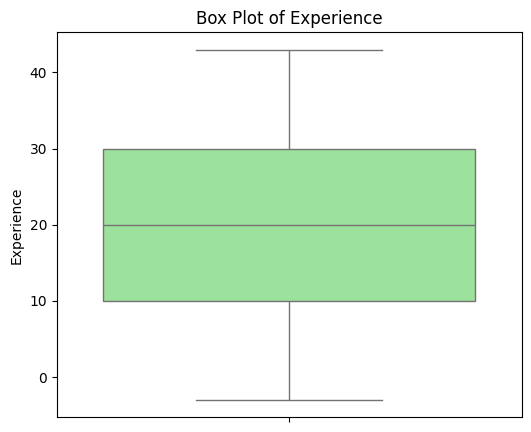

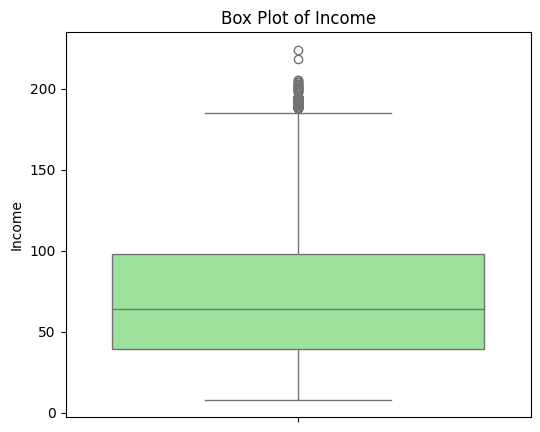

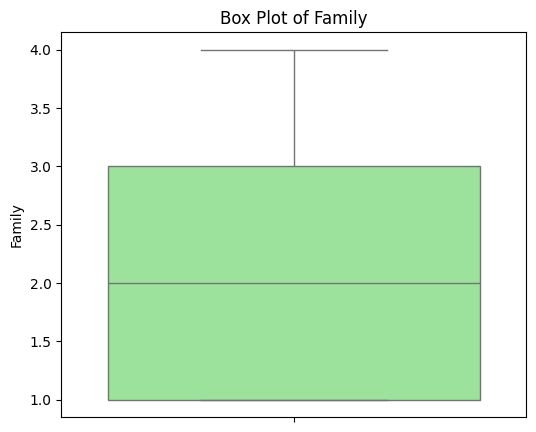

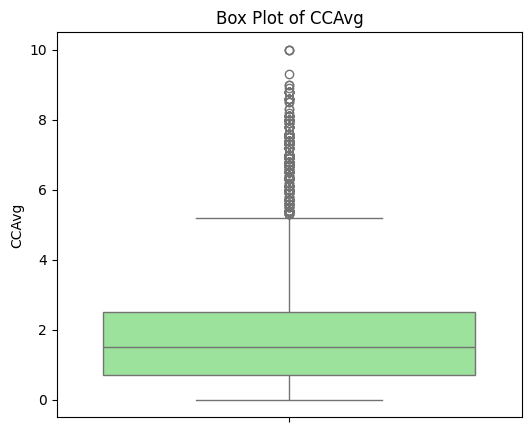

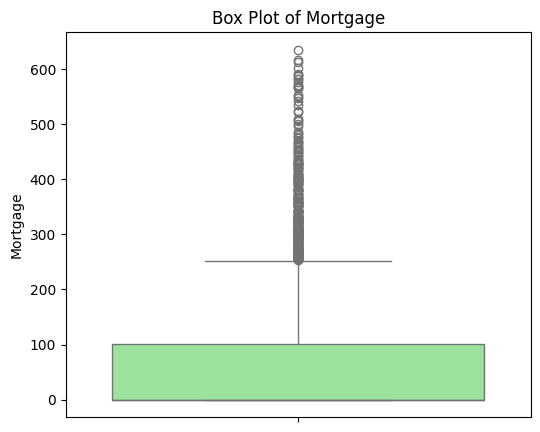

In [21]:
#Box plot
for col in numerical_cols:
    plt.figure(figsize=(6,5))
    sns.boxplot(y=df[col],
                color='lightgreen')
    plt.title(f'Box Plot of {col}')
    plt.show()

#Bivariate Analysis

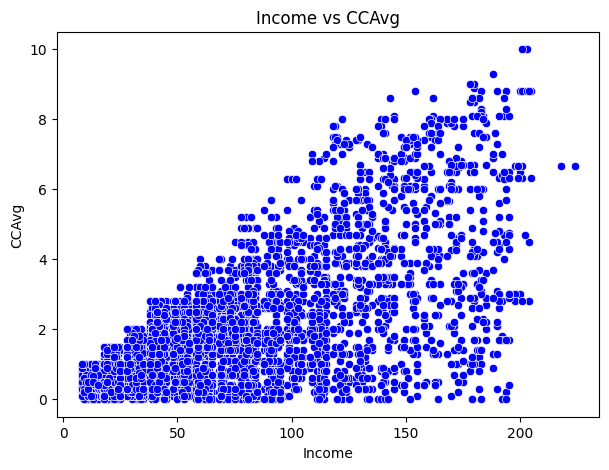

In [22]:
#Scatter Plot (Income vs CCAvg)
#Shows the relationship between customer income and average credit card spending.
plt.figure(figsize=(7,5))
sns.scatterplot(x='Income',
                y='CCAvg',
                data=df,
                color='blue')
plt.title('Income vs CCAvg')
plt.xlabel('Income')
plt.ylabel('CCAvg')
plt.show()

There is a positive correlation between Income and CCAvg.
As customer income increases, the average credit card spending also tends to increase.Most customers are concentrated in the income range of approximately 20 to 100, with a CCAvg between 0 and 3.

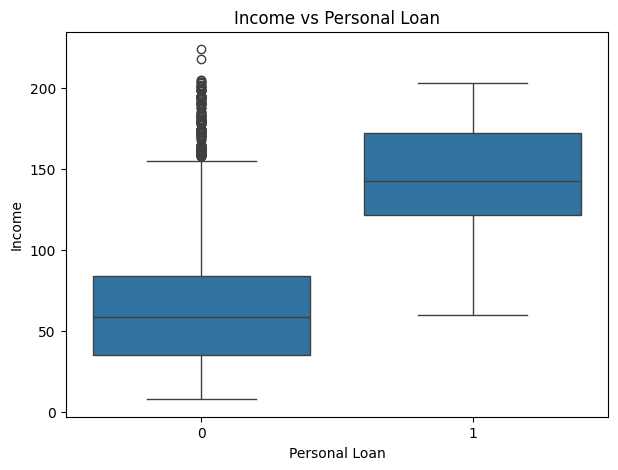

In [23]:
#Box Plot (Income vs Personal Loan)
plt.figure(figsize=(7,5))
sns.boxplot(
    x='Personal Loan',
    y='Income',
    data=df
)
plt.title("Income vs Personal Loan")
plt.xlabel("Personal Loan")
plt.ylabel("Income")
plt.show()

Customers with personal loans generally have higher incomes.
Outliers indicate customers with exceptionally high income.

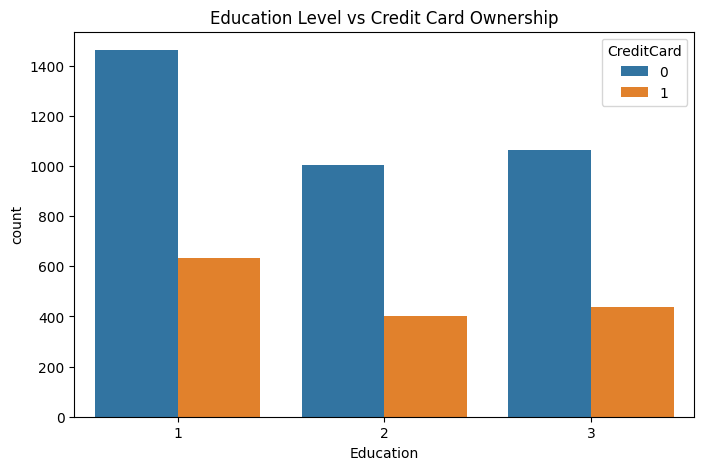

In [24]:
#Grouped Count Plot (Education vs Credit Card)
plt.figure(figsize=(8,5))
sns.countplot(
    x='Education',
    hue='CreditCard',
    data=df
)
plt.title("Education Level vs Credit Card Ownership")
plt.show()

Compares the number of credit card holders across education levels.

#Multivariate Analysis

In [25]:
#Computing correlation matrix
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)

                          ID       Age  Experience    Income  ZIP Code  \
ID                  1.000000 -0.008473   -0.008326 -0.017695  0.013432   
Age                -0.008473  1.000000    0.994215 -0.055269 -0.029216   
Experience         -0.008326  0.994215    1.000000 -0.046574 -0.028626   
Income             -0.017695 -0.055269   -0.046574  1.000000 -0.016410   
ZIP Code            0.013432 -0.029216   -0.028626 -0.016410  1.000000   
Family             -0.016797 -0.046418   -0.052563 -0.157501  0.011778   
CCAvg              -0.024675 -0.052012   -0.050077  0.645984 -0.004061   
Education           0.021463  0.041334    0.013152 -0.187524 -0.017377   
Mortgage           -0.013920 -0.012539   -0.010582  0.206806  0.007383   
Personal Loan      -0.024801 -0.007726   -0.007413  0.502462  0.000107   
Securities Account -0.016972 -0.000436   -0.001232 -0.002616  0.004704   
CD Account         -0.006909  0.008043    0.010353  0.169738  0.019972   
Online             -0.002528  0.013702

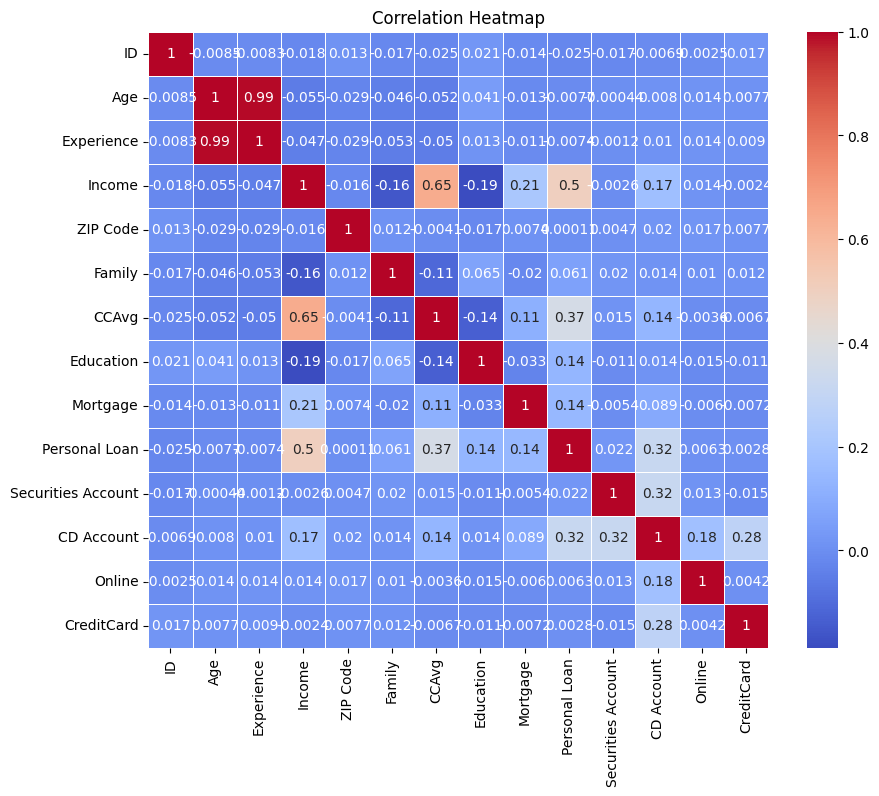

In [26]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

Strong positive correlations appear in darker red shades.
Strong negative correlations appear in darker blue shades.
Age and Experience usually have a very high positive correlation.
Income shows a positive relationship with CCAvg and Mortgage.

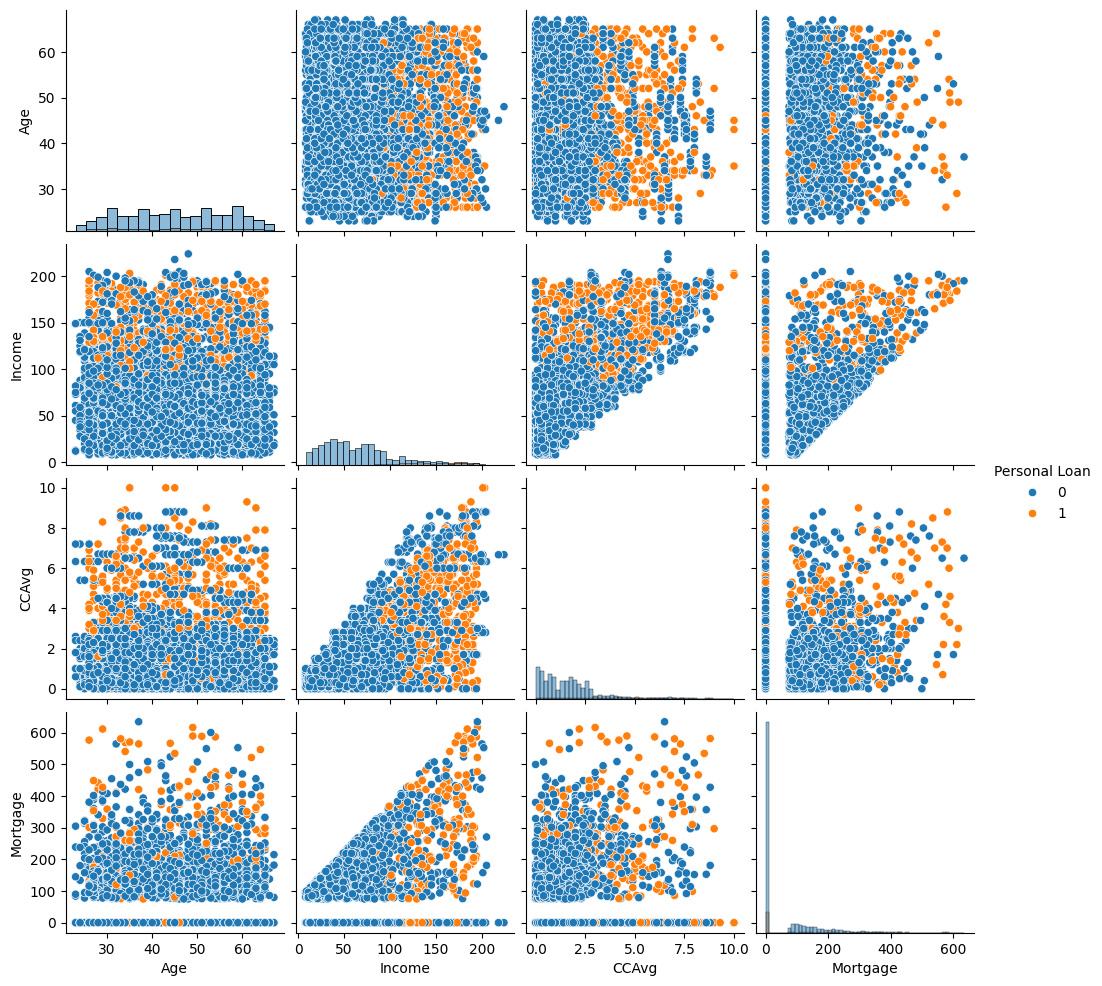

In [27]:
#Pair Plot
num_columns = [
    'Age',
    'Income',
    'CCAvg',
    'Mortgage',
    'Personal Loan'
]
sns.pairplot(
    df[num_columns],
    hue='Personal Loan',
    diag_kind='hist'
)
plt.show()

Histograms on the diagonal show the distribution of each variable.Income and CCAvg exhibit a positive trend.
Customers taking personal loans are generally clustered in higher income and higher CCAvg regions.

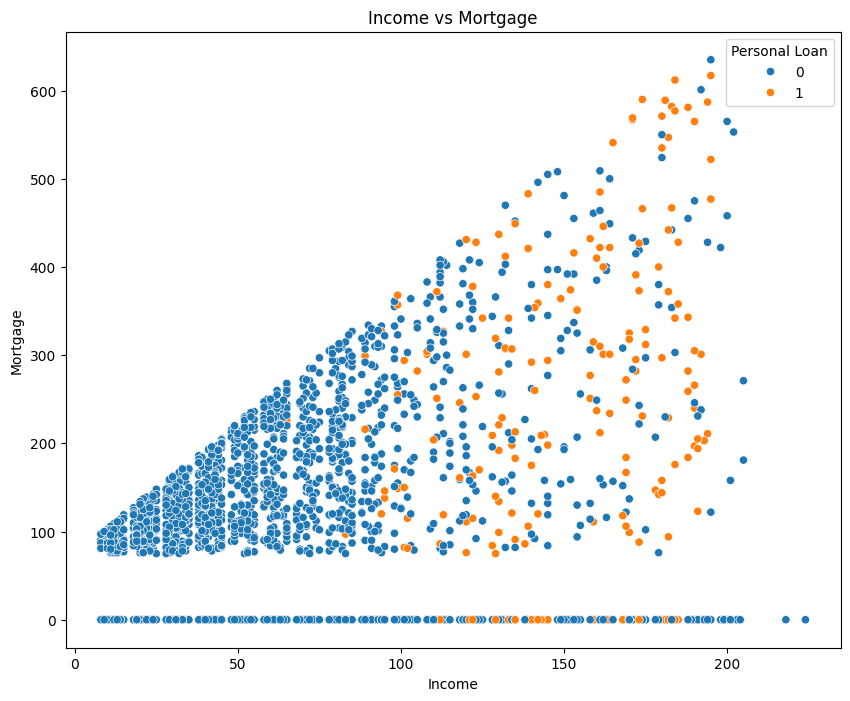

In [28]:
#Scatter Plot (Income vs Mortgage vs Personal Loan)
plt.figure(figsize=(10,8))
sns.scatterplot(
    x='Income',
    y='Mortgage',
    hue='Personal Loan',
    data=df)
plt.title("Income vs Mortgage")
plt.xlabel("Income")
plt.ylabel("Mortgage")
plt.show()

Higher-income customers generally have larger mortgages.Colour indicates whether the customer has taken a personal loan.

# 1D Analysis


In [29]:
numerical_cols = [
    'Age',
    'Experience',
    'Income',
    'Family',
    'CCAvg',
    'Mortgage'
]

categorical_cols = [
    'Education',
    'Personal Loan',
    'Securities Account',
    'CD Account',
    'Online',
    'CreditCard'
]

identifier_cols = [
    'ID',
    'ZIP Code'
]

In [30]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0


In [31]:
summary_1d = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Mode': df[numerical_cols].mode().iloc[0],
    'Std Dev': df[numerical_cols].std(),
    'Variance': df[numerical_cols].var(),
    'Minimum': df[numerical_cols].min(),
    'Maximum': df[numerical_cols].max(),
    'Range': df[numerical_cols].max() - df[numerical_cols].min(),
    'Skewness': df[numerical_cols].skew(),
    'Kurtosis': df[numerical_cols].kurtosis()
})

summary_1d.round(3)

,Mean,Median,Mode,Std Dev,Variance,Minimum,Maximum,Range,Skewness,Kurtosis
Age,45.338,45.0,35.0,11.463,131.404,23.0,67.0,44.0,-0.029,-1.153
Experience,20.105,20.0,32.0,11.468,131.514,-3.0,43.0,46.0,-0.026,-1.122
Income,73.774,64.0,44.0,46.034,2119.104,8.0,224.0,216.0,0.841,-0.044
Family,2.396,2.0,1.0,1.148,1.317,1.0,4.0,3.0,0.155,-1.404
CCAvg,1.938,1.5,0.3,1.748,3.054,0.0,10.0,10.0,1.598,2.647
Mortgage,56.499,0.0,0.0,101.714,10345.698,0.0,635.0,635.0,2.104,4.757


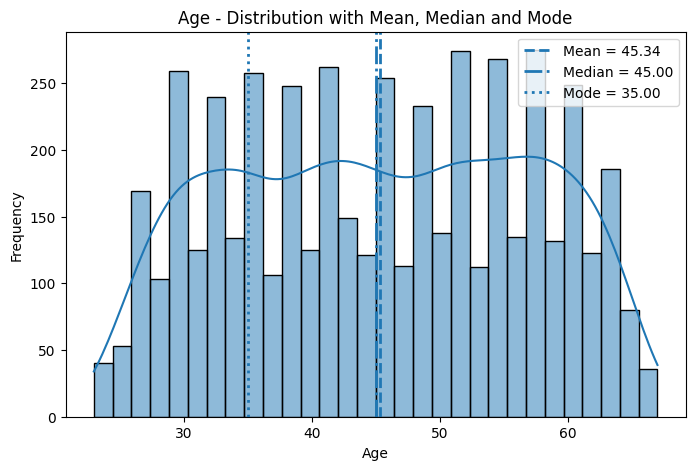

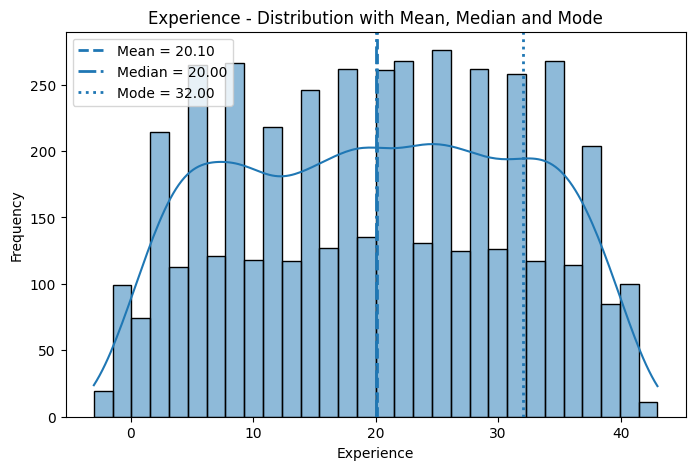

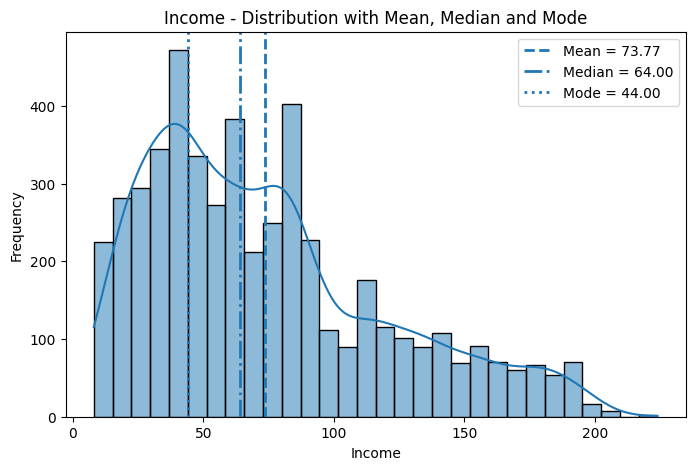

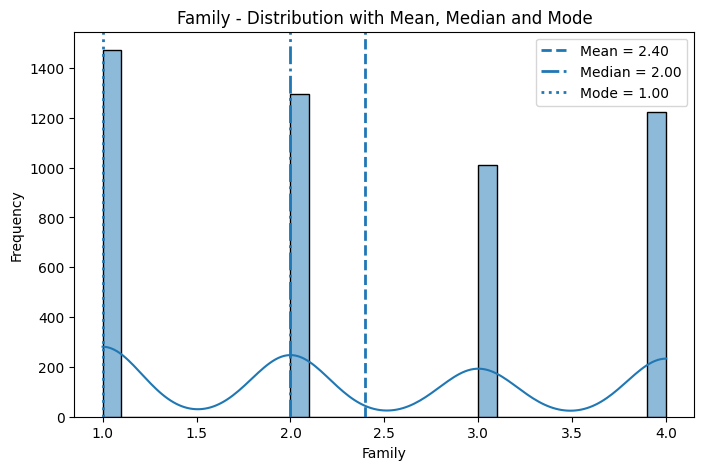

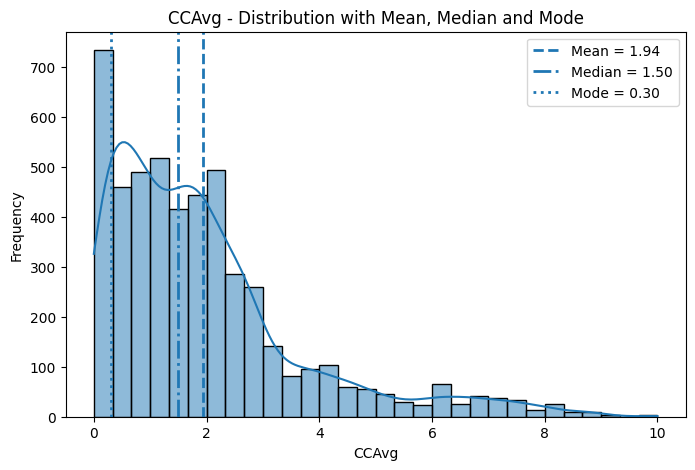

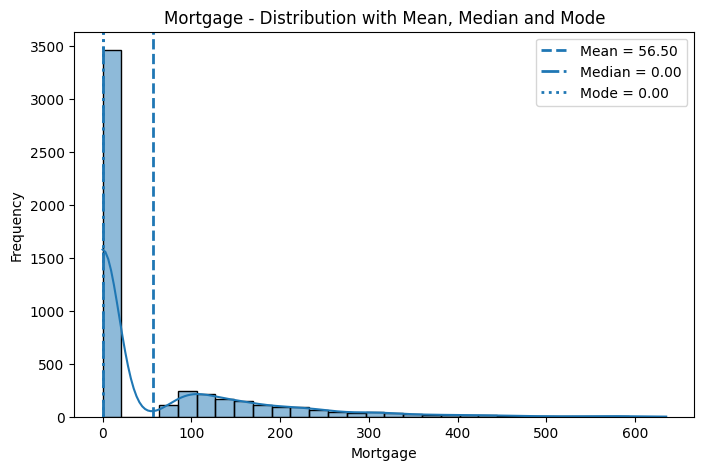

In [32]:
for col in numerical_cols:

    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0]

    plt.figure(figsize=(8, 5))

    sns.histplot(df[col], bins=30, kde=True)

    plt.axvline(mean_val, linestyle='--', linewidth=2,
                label=f'Mean = {mean_val:.2f}')

    plt.axvline(median_val, linestyle='-.', linewidth=2,
                label=f'Median = {median_val:.2f}')

    plt.axvline(mode_val, linestyle=':', linewidth=2,
                label=f'Mode = {mode_val:.2f}')

    plt.title(f'{col} - Distribution with Mean, Median and Mode')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()

    plt.show()

In [33]:
skewness = df[numerical_cols].skew().sort_values()

print(skewness)

Age          -0.029341
Experience   -0.026325
Family        0.155221
Income        0.841339
CCAvg         1.598443
Mortgage      2.104002
dtype: float64


In [34]:
outlier_results = []

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_results.append([
        col,
        Q1,
        Q3,
        IQR,
        lower,
        upper,
        count
    ])

outlier_df = pd.DataFrame(
    outlier_results,
    columns=[
        'Variable',
        'Q1',
        'Q3',
        'IQR',
        'Lower Bound',
        'Upper Bound',
        'Outlier Count'
    ]
)

outlier_df

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Age,35.0,55.0,20.0,5.0,85.0,0
1,Experience,10.0,30.0,20.0,-20.0,60.0,0
2,Income,39.0,98.0,59.0,-49.5,186.5,96
3,Family,1.0,3.0,2.0,-2.0,6.0,0
4,CCAvg,0.7,2.5,1.8,-2.0,5.2,324
5,Mortgage,0.0,101.0,101.0,-151.5,252.5,291


In [37]:
for col in categorical_cols:

    print("\n")
    print(col)

    print(df[col].value_counts())



Education
Education
1    2096
3    1501
2    1403
Name: count, dtype: int64


Personal Loan
Personal Loan
0    4520
1     480
Name: count, dtype: int64


Securities Account
Securities Account
0    4478
1     522
Name: count, dtype: int64


CD Account
CD Account
0    4698
1     302
Name: count, dtype: int64


Online
Online
1    2984
0    2016
Name: count, dtype: int64


CreditCard
CreditCard
0    3530
1    1470
Name: count, dtype: int64


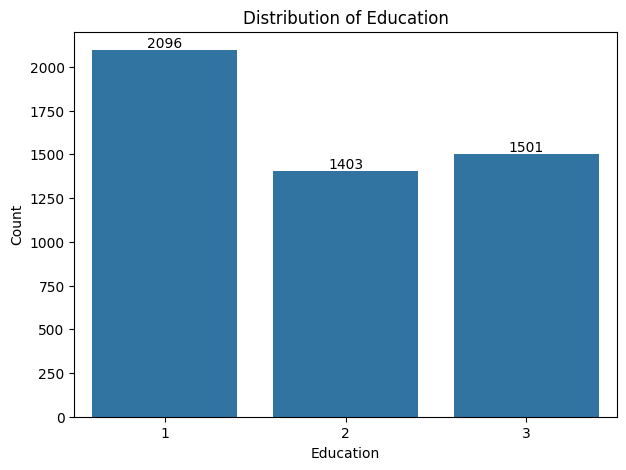

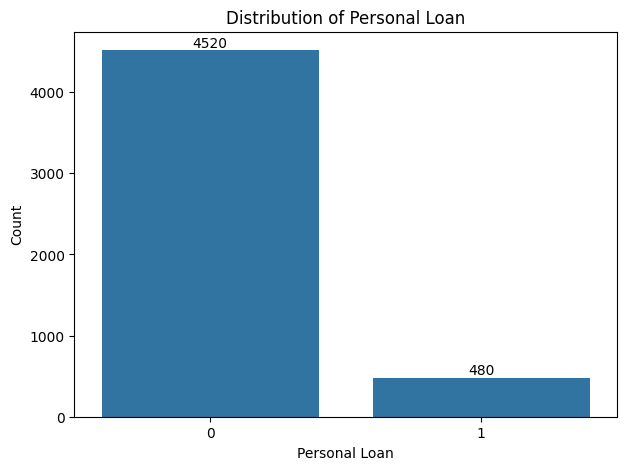

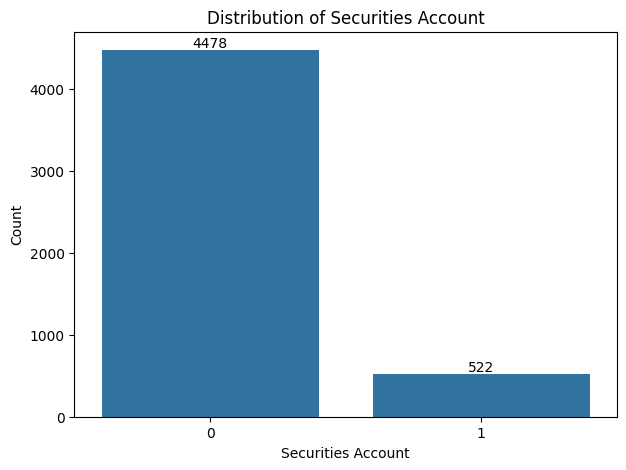

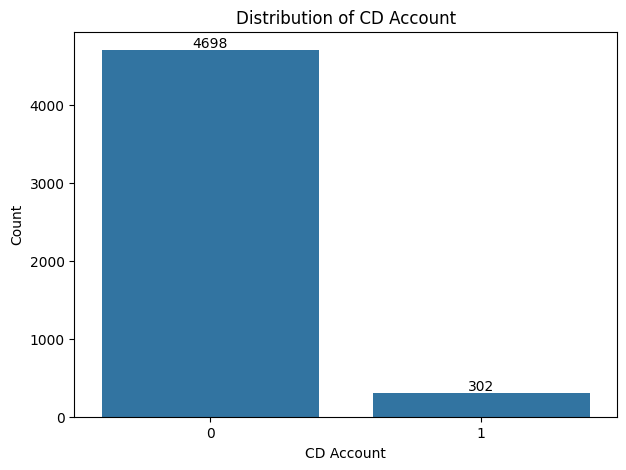

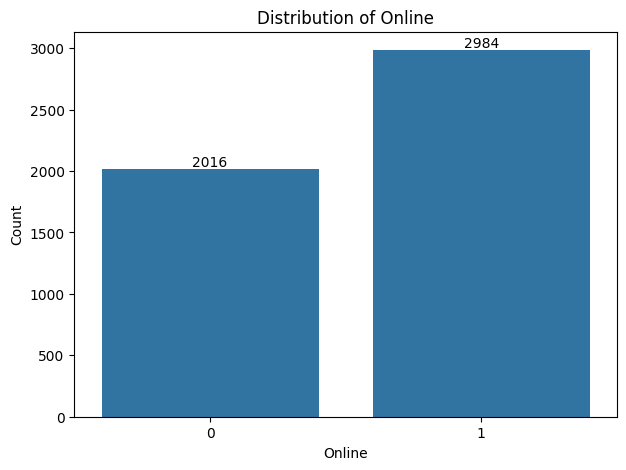

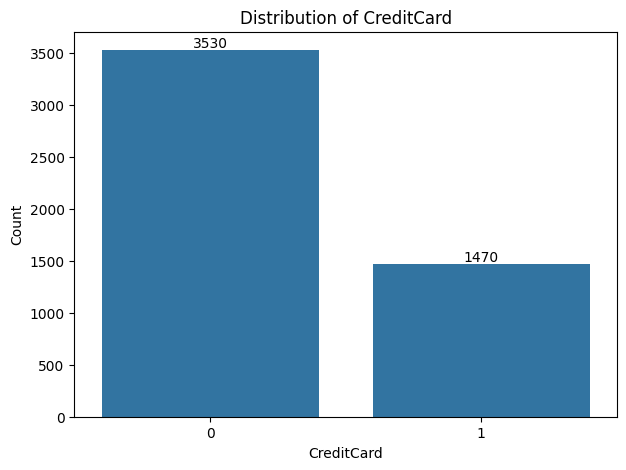

In [38]:
for col in categorical_cols:

    plt.figure(figsize=(7, 5))

    ax = sns.countplot(
        x=col,
        data=df
    )

    for container in ax.containers:
        ax.bar_label(container)

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

    plt.show()

#2D Analysis

In [39]:
#Correlation Matrix
correlation_matrix = df[numerical_cols].corr()

correlation_matrix.round(3)

,Age,Experience,Income,Family,CCAvg,Mortgage
Age,1.000,0.994,-0.055,-0.046,-0.052,-0.013
Experience,0.994,1.000,-0.047,-0.053,-0.050,-0.011
Income,-0.055,-0.047,1.000,-0.158,0.646,0.207
Family,-0.046,-0.053,-0.158,1.000,-0.109,-0.020
CCAvg,-0.052,-0.050,0.646,-0.109,1.000,0.110
Mortgage,-0.013,-0.011,0.207,-0.020,0.110,1.000


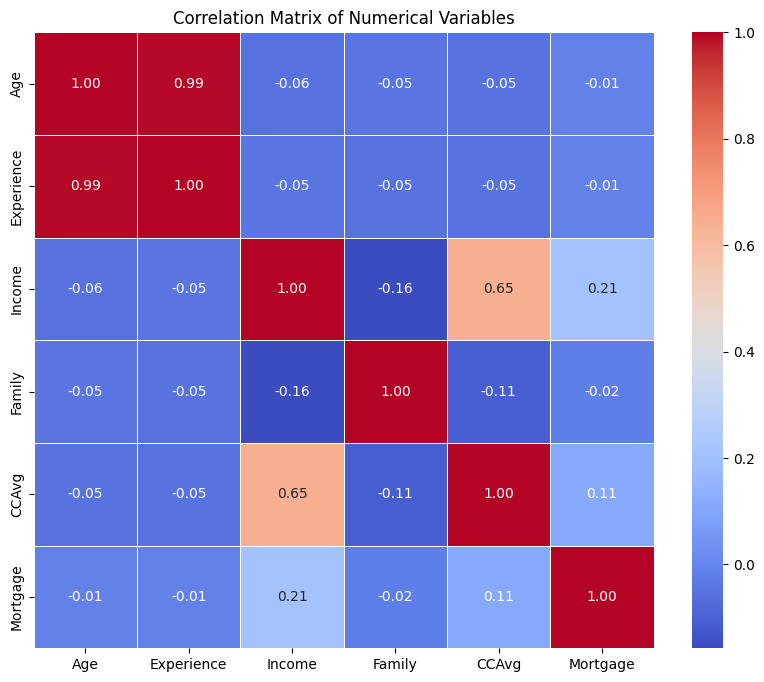

In [40]:
#Correlation Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

In [41]:
#Pearson and Spearman Correlation
#Pearson measures linear correlation, while Spearman measures monotonic association and is less sensitive to extreme values.

pearson = df[numerical_cols].corr(method='pearson')
spearman = df[numerical_cols].corr(method='spearman')

print("PEARSON CORRELATION")
display(pearson.round(3))

print("\nSPEARMAN CORRELATION")
display(spearman.round(3))

PEARSON CORRELATION


,Age,Experience,Income,Family,CCAvg,Mortgage
Age,1.000,0.994,-0.055,-0.046,-0.052,-0.013
Experience,0.994,1.000,-0.047,-0.053,-0.050,-0.011
Income,-0.055,-0.047,1.000,-0.158,0.646,0.207
Family,-0.046,-0.053,-0.158,1.000,-0.109,-0.020
CCAvg,-0.052,-0.050,0.646,-0.109,1.000,0.110
Mortgage,-0.013,-0.011,0.207,-0.020,0.110,1.000



SPEARMAN CORRELATION


,Age,Experience,Income,Family,CCAvg,Mortgage
Age,1.000,0.994,-0.057,-0.044,-0.050,-0.011
Experience,0.994,1.000,-0.050,-0.049,-0.051,-0.009
Income,-0.057,-0.050,1.000,-0.133,0.580,0.061
Family,-0.044,-0.049,-0.133,1.000,-0.070,-0.001
CCAvg,-0.050,-0.051,0.580,-0.070,1.000,0.024
Mortgage,-0.011,-0.009,0.061,-0.001,0.024,1.000


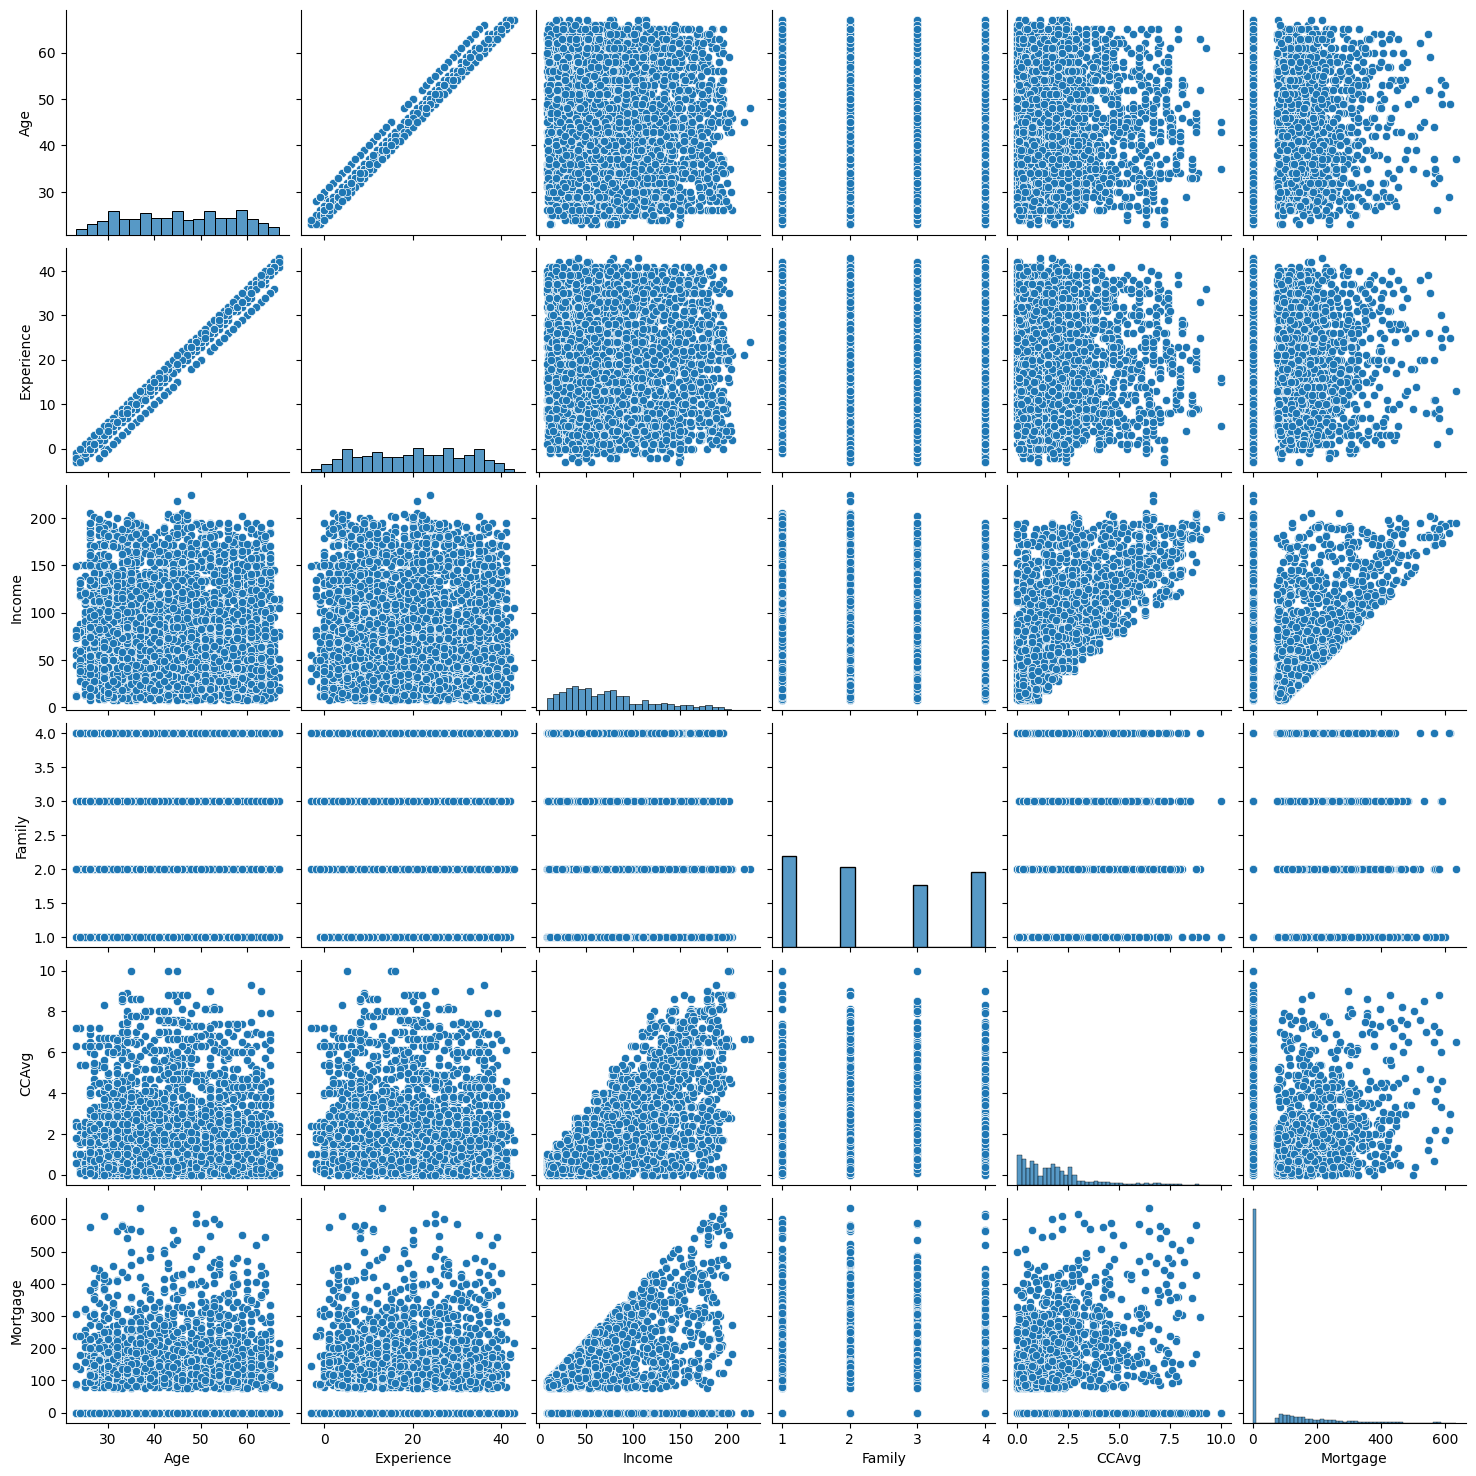

In [42]:
sns.pairplot(
    df[numerical_cols],
    diag_kind='hist'
)

plt.show()

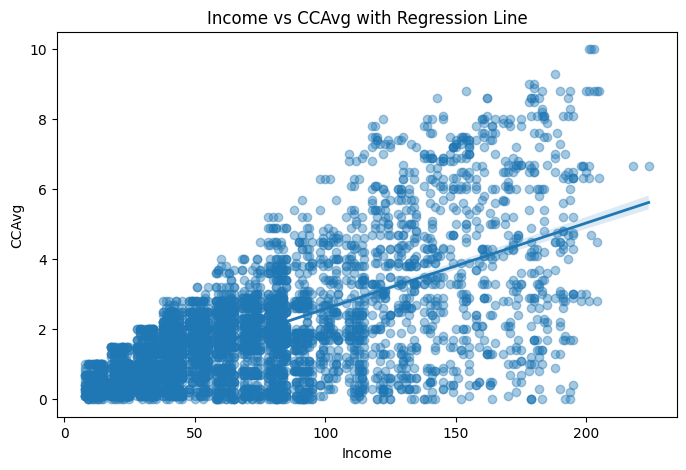

Pearson correlation: 0.646


In [44]:
#Regression Analysis
#Income vs CCAvg
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x='Income',
    y='CCAvg',
    scatter_kws={'alpha': 0.4},
    line_kws={'linewidth': 2}
)

plt.title('Income vs CCAvg with Regression Line')
plt.show()

r = df['Income'].corr(df['CCAvg'])

print("Pearson correlation:", round(r, 3))

This indicates a moderately strong positive linear relationship

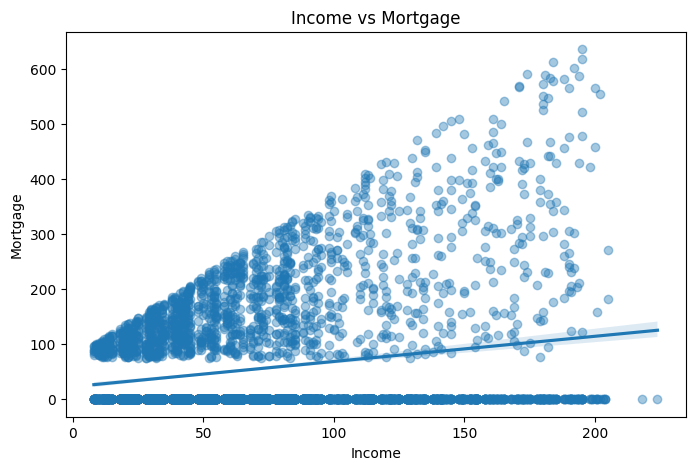

Correlation: 0.207


In [45]:
#Income vs Mortgage

plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x='Income',
    y='Mortgage',
    scatter_kws={'alpha': 0.4}
)

plt.title('Income vs Mortgage')

plt.show()

print(
    "Correlation:",
    round(df['Income'].corr(df['Mortgage']), 3)
)

The relationship is positive but relatively weak.

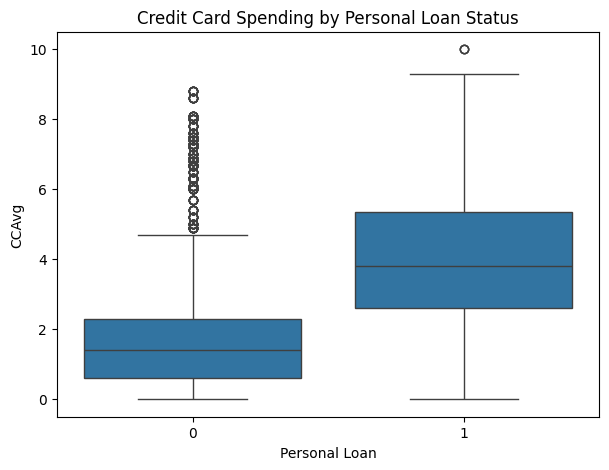

Correlation: 0.367


In [46]:
#CCAvg vs Personal Loan

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x='Personal Loan',
    y='CCAvg'
)

plt.title('Credit Card Spending by Personal Loan Status')

plt.show()

print(
    "Correlation:",
    round(df['CCAvg'].corr(df['Personal Loan']), 3)
)

In [47]:
#Education vs Personal Loan
education_loan = pd.crosstab(
    df['Education'],
    df['Personal Loan']
)

print(education_loan)

Personal Loan     0    1
Education               
1              2003   93
2              1221  182
3              1296  205


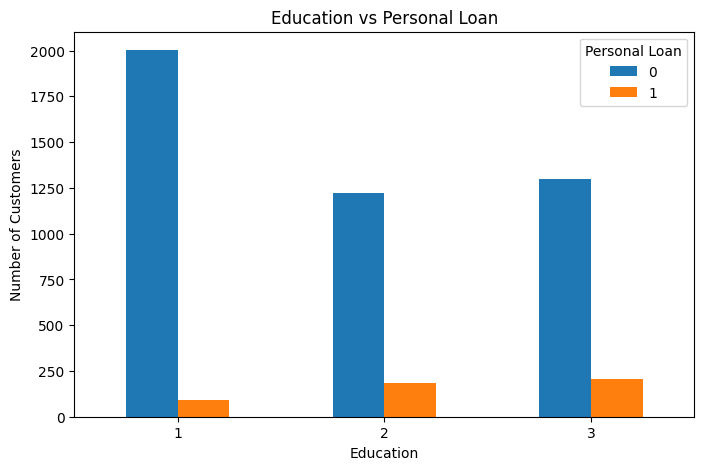

In [48]:
education_loan.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Education vs Personal Loan')
plt.xlabel('Education')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)

plt.show()

In [49]:
#Chi Square Test

chi_table = pd.crosstab(
    df['Education'],
    df['Personal Loan']
)

chi2, p, dof, expected = stats.chi2_contingency(chi_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 111.2398718738913
p-value: 6.991473868665428e-25
Degrees of freedom: 2


#3D Analysis

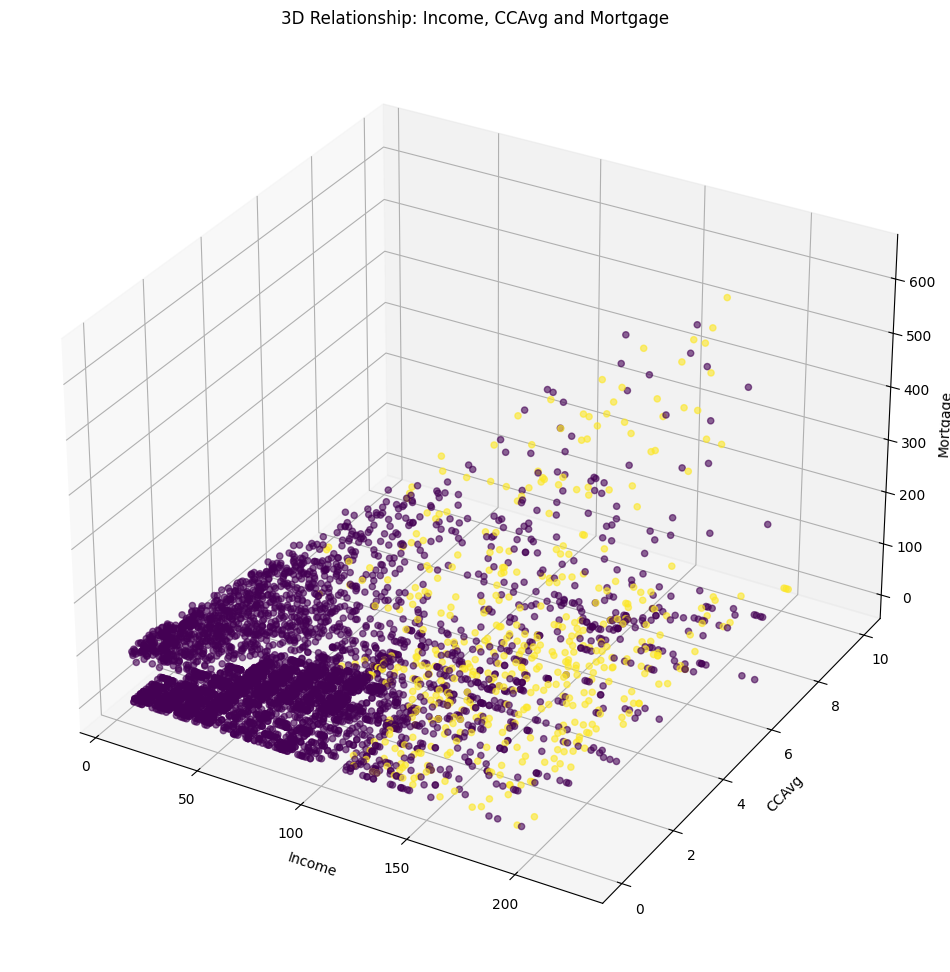

In [55]:
#3D Scatter Plot
#Visualizing relationship between Income, CCavg, & Mortgage, using Personal Loan as color
fig = plt.figure(figsize=(12, 16))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['Income'],
    df['CCAvg'],
    df['Mortgage'],
    c=df['Personal Loan'],
    cmap='viridis',
    alpha=0.6
)

ax.set_xlabel('Income')
ax.set_ylabel('CCAvg')
ax.set_zlabel('Mortgage')

ax.set_title(
    '3D Relationship: Income, CCAvg and Mortgage'
)

plt.show()

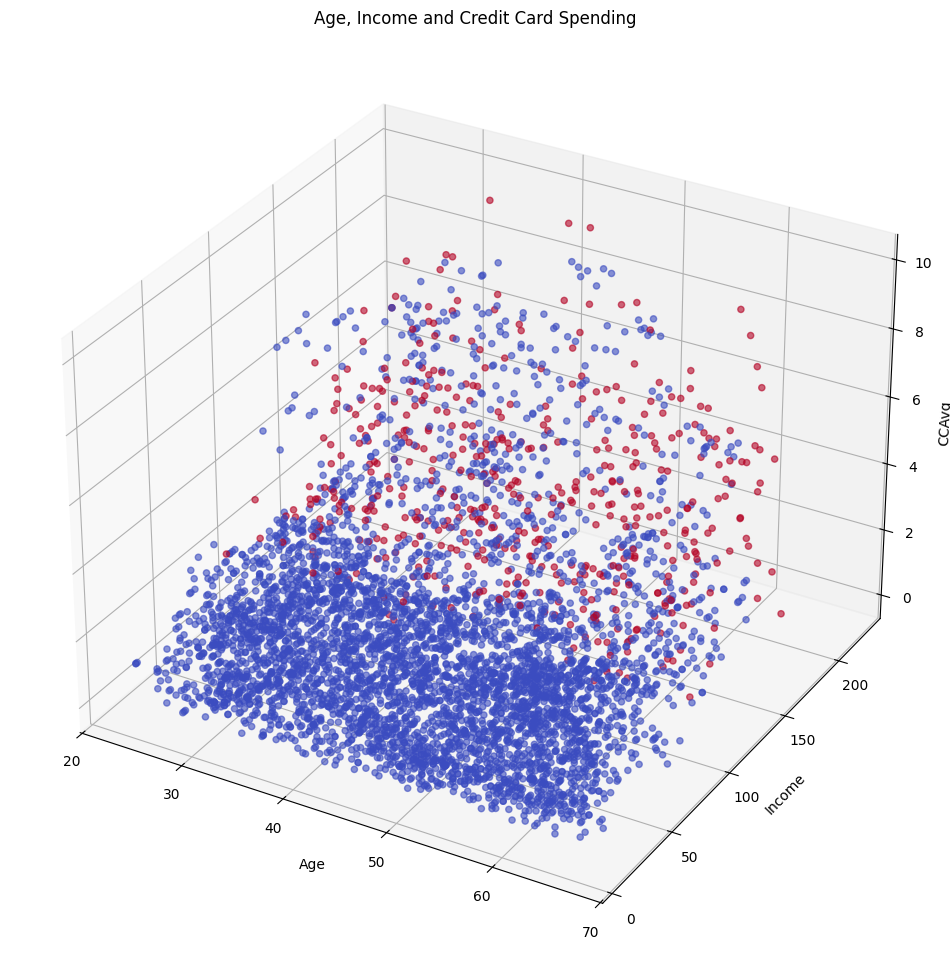

In [57]:
#3D Scatter — Age, Income and CCAvg
fig = plt.figure(figsize=(12, 16))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['Age'],
    df['Income'],
    df['CCAvg'],
    c=df['Personal Loan'],
    cmap='coolwarm',
    alpha=0.6
)

ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_zlabel('CCAvg')

ax.set_title(
    'Age, Income and Credit Card Spending'
)

plt.show()

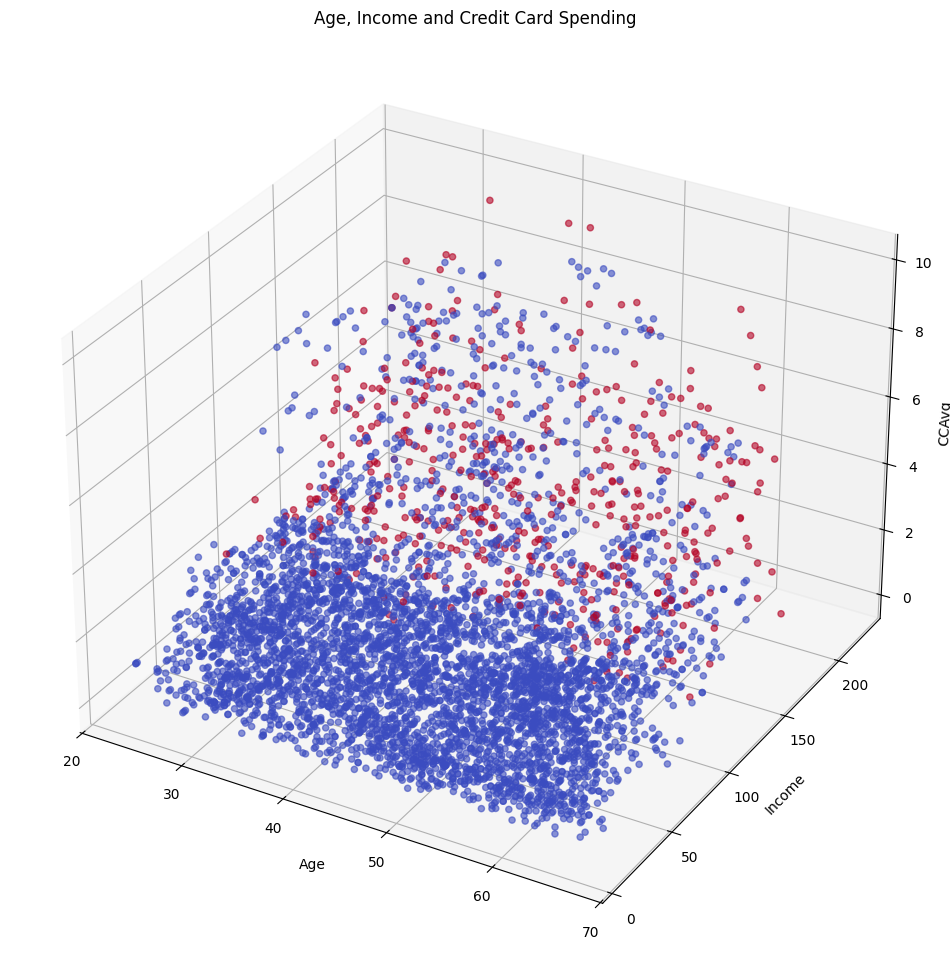

In [59]:
#Bubble Plot
fig = plt.figure(figsize=(12, 16b))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['Age'],
    df['Income'],
    df['CCAvg'],
    c=df['Personal Loan'],
    cmap='coolwarm',
    alpha=0.6
)

ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_zlabel('CCAvg')

ax.set_title(
    'Age, Income and Credit Card Spending'
)

plt.show()

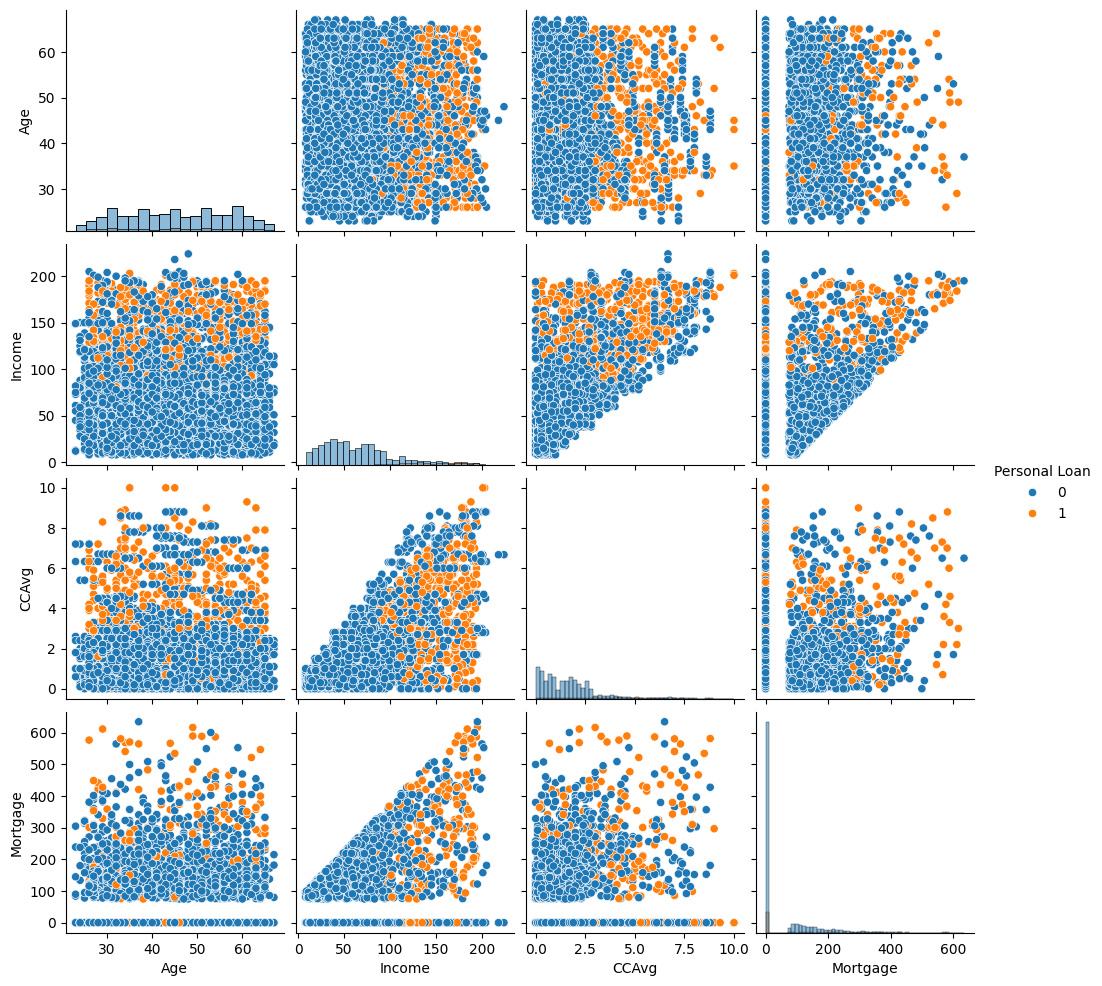

In [60]:
#Pair Plot with Personal Loan

selected = [
    'Age',
    'Income',
    'CCAvg',
    'Mortgage',
    'Personal Loan'
]

sns.pairplot(
    df[selected],
    hue='Personal Loan',
    diag_kind='hist'
)

plt.show()

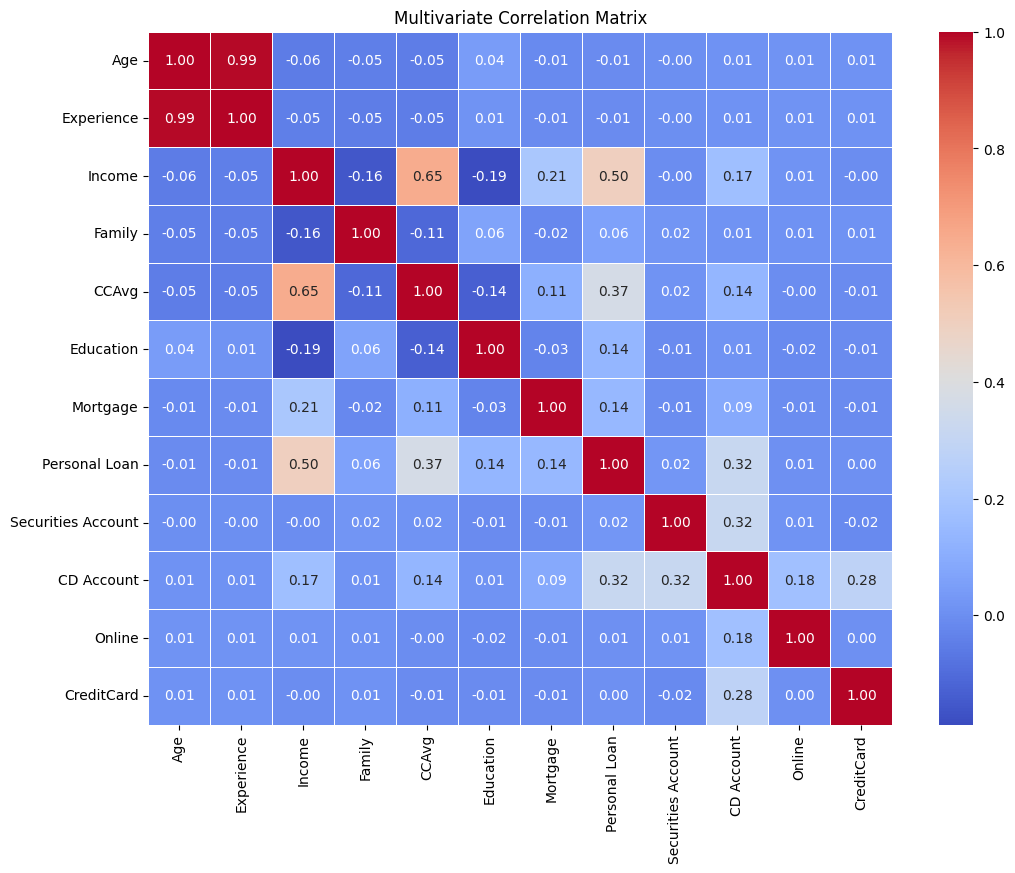

In [61]:
#Multivariate Correlation Heatmap
plt.figure(figsize=(12, 9))

corr = df.drop(columns=['ID', 'ZIP Code']).corr(
    numeric_only=True
)

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Multivariate Correlation Matrix')

plt.show()

In [62]:
#Multiple Linear Regression

X = df[
    ['Age',
     'Experience',
     'Family',
     'CCAvg',
     'Education',
     'Mortgage']
]

y = df['Income']

model = LinearRegression()

model.fit(X, y)

print("Intercept:", model.intercept_)

coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_
})

coefficients

Intercept: 96.8392868144523


,Variable,Coefficient
0,Age,-1.566214
1,Experience,1.484944
2,Family,-3.265714
3,CCAvg,16.045799
4,Education,-4.581006
5,Mortgage,0.060840


#K-Means Clustering


In [64]:
#Cluster Features
cluster_features = [
    'Age',
    'Experience',
    'Income',
    'Family',
    'CCAvg',
    'Education',
    'Mortgage'
]

X = df[cluster_features].copy()

print(X.head())

   Age  Experience  Income  Family  CCAvg  Education  Mortgage
0   25           1      49       4    1.6          1         0
1   45          19      34       3    1.5          1         0
2   39          15      11       1    1.0          1         0
3   35           9     100       1    2.7          2         0
4   35           8      45       4    1.0          2         0


In [65]:
#Standardize the Data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=cluster_features
)

X_scaled.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage
0,-1.774417,-1.666078,-0.538229,1.397414,-0.193385,-1.049078,-0.555524
1,-0.029524,-0.096330,-0.864109,0.525991,-0.250611,-1.049078,-0.555524
2,-0.552992,-0.445163,-1.363793,-1.216855,-0.536736,-1.049078,-0.555524
3,-0.901970,-0.968413,0.569765,-1.216855,0.436091,0.141703,-0.555524
4,-0.901970,-1.055621,-0.625130,1.397414,-0.536736,0.141703,-0.555524


In [66]:
#Finding the Optimal Number of Clusters Using the Elbow Method
from sklearn.cluster import KMeans

inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

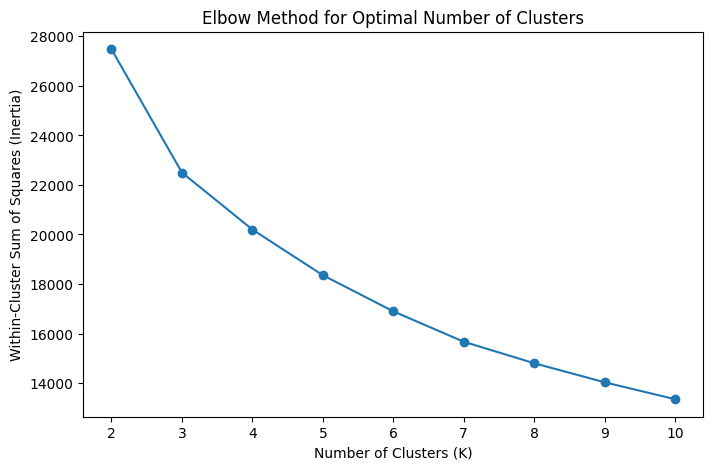

In [67]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (Inertia)')

plt.xticks(K)
plt.show()

In [68]:
#K_means Clustering with 3 clusters
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'].value_counts().sort_index()

,count
KMeans_Cluster,
0,858
1,2007
2,2135


In [70]:
#Cluster Centers
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=cluster_features
)

cluster_centers

,Age,Experience,Income,Family,CCAvg,Education,Mortgage
0,-0.120632,-0.101412,1.563131,-0.423637,1.591391,-0.445360,0.584976
1,-0.892407,-0.893805,-0.295147,0.182545,-0.318890,0.084745,-0.115653
2,0.887383,0.880974,-0.350729,-0.001353,-0.339767,0.099314,-0.126367


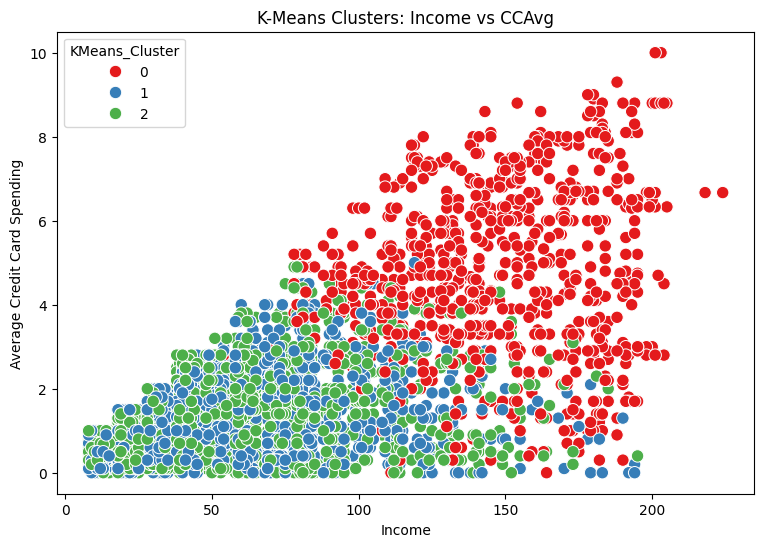

In [71]:
#Visualizing the clusters
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Income',
    y='CCAvg',
    hue='KMeans_Cluster',
    palette='Set1',
    s=80
)

plt.title('K-Means Clusters: Income vs CCAvg')
plt.xlabel('Income')
plt.ylabel('Average Credit Card Spending')

plt.show()

K-Means clustering was applied to segment customers based on Age, Experience, Income, Family, CCAvg, Education, and Mortgage. Before clustering, the numerical variables were standardized using StandardScaler because K-Means uses distance calculations and variables with larger scales could otherwise dominate the clustering process. The Elbow Method was used to examine the appropriate number of clusters. Customers were then assigned to three clusters, and the resulting clusters were profiled using their mean characteristics.

#Hierarchial Clustering

In [73]:
#Calculate the Euclidean Distance
distance_matrix = squareform(
    pdist(X_scaled, metric='euclidean')
)

distance_matrix

array([[0.        , 2.52539364, 3.25827606, ..., 5.61524575, 5.1302839 ,
        1.28512049],
       [2.52539364, 0.        , 1.94030079, ..., 3.52962482, 2.87231754,
        2.28137287],
       [3.25827606, 1.94030079, 0.        , ..., 3.92891596, 3.88814301,
        2.7089967 ],
       ...,
       [5.61524575, 3.52962482, 3.92891596, ..., 0.        , 1.58854736,
        5.17656234],
       [5.1302839 , 2.87231754, 3.88814301, ..., 1.58854736, 0.        ,
        4.71909053],
       [1.28512049, 2.28137287, 2.7089967 , ..., 5.17656234, 4.71909053,
        0.        ]])

In [75]:
#Hierarchical Clustering — Ward's Method
from scipy.cluster.hierarchy import linkage, dendrogram

linkage_ward = linkage(
    X_scaled,
    method='ward',
    metric='euclidean'
)

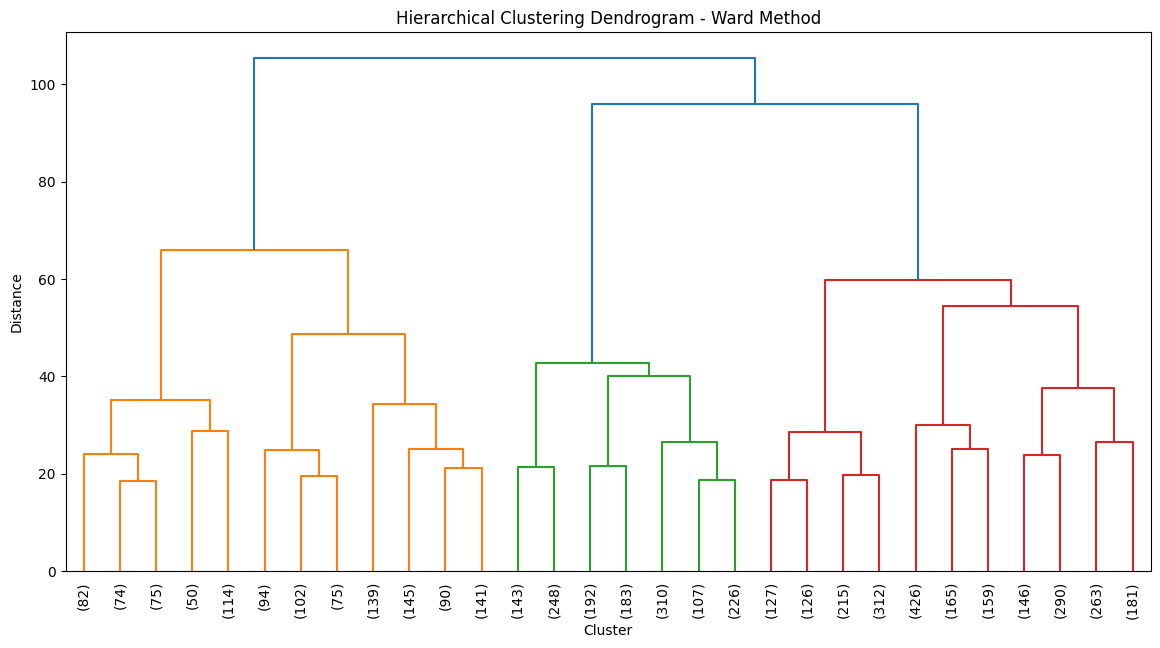

In [76]:
#Plot Dendogram
plt.figure(figsize=(14,7))

dendrogram(
    linkage_ward,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title('Hierarchical Clustering Dendrogram - Ward Method')
plt.xlabel('Cluster')
plt.ylabel('Distance')

plt.show()

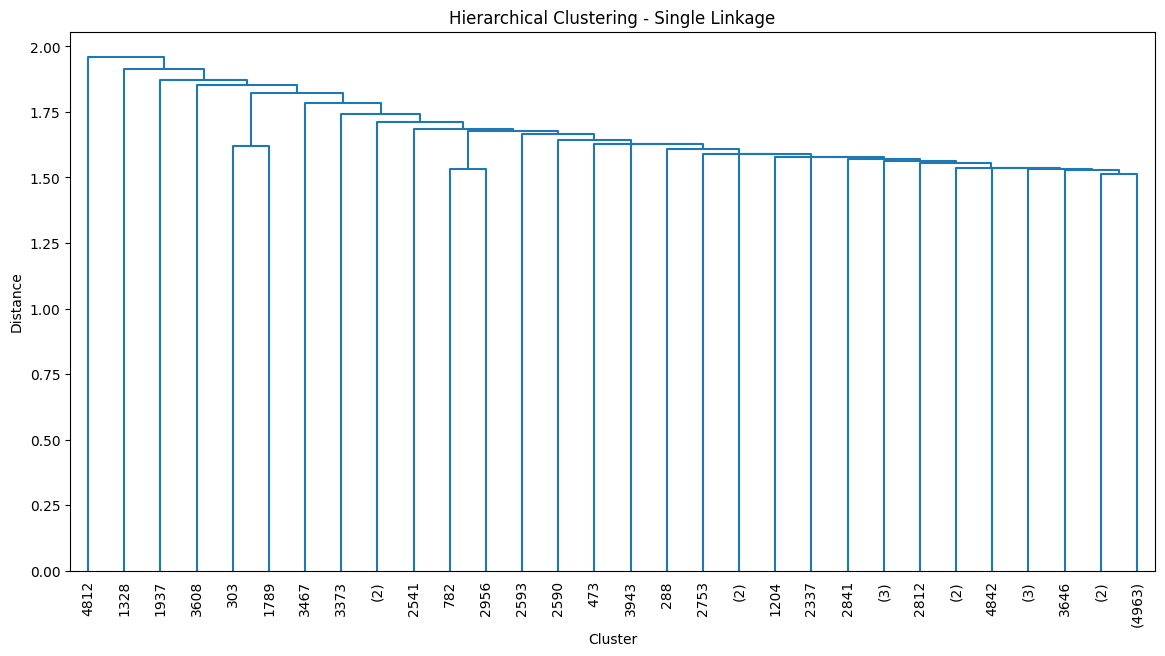

In [77]:
#Single Linkage
linkage_single = linkage(
    X_scaled,
    method='single',
    metric='euclidean'
)
plt.figure(figsize=(14,7))

dendrogram(
    linkage_single,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90
)

plt.title('Hierarchical Clustering - Single Linkage')
plt.xlabel('Cluster')
plt.ylabel('Distance')

plt.show()

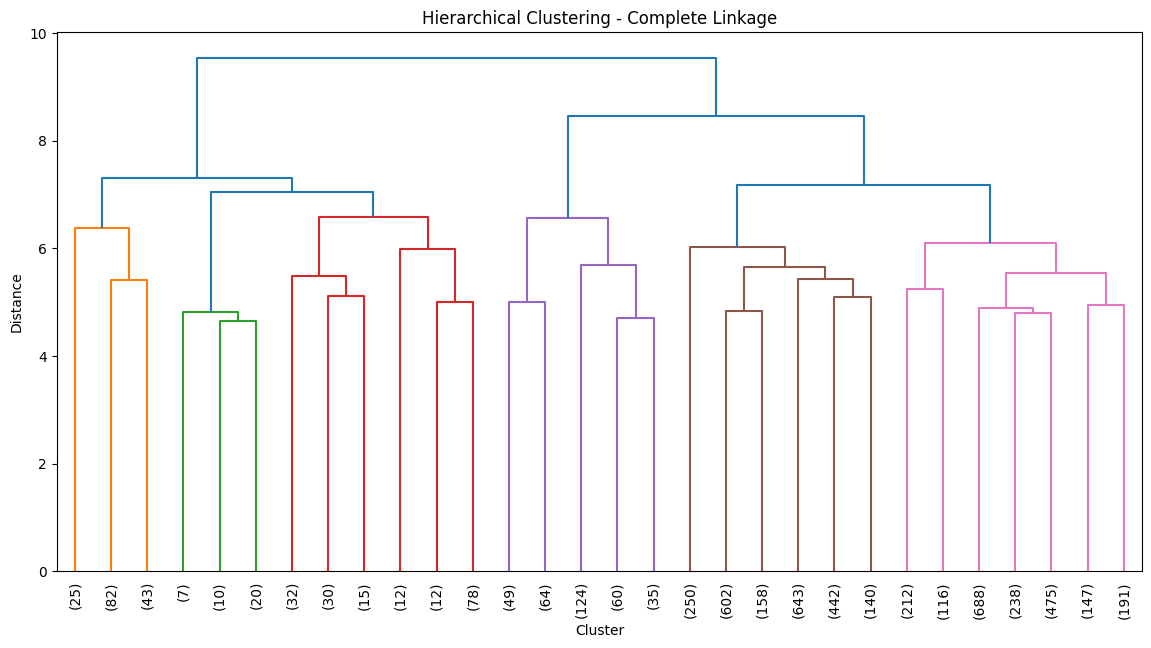

In [78]:
#Complete Linkage
linkage_complete = linkage(
    X_scaled,
    method='complete',
    metric='euclidean'
)
plt.figure(figsize=(14,7))

dendrogram(
    linkage_complete,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90
)

plt.title('Hierarchical Clustering - Complete Linkage')
plt.xlabel('Cluster')
plt.ylabel('Distance')

plt.show()

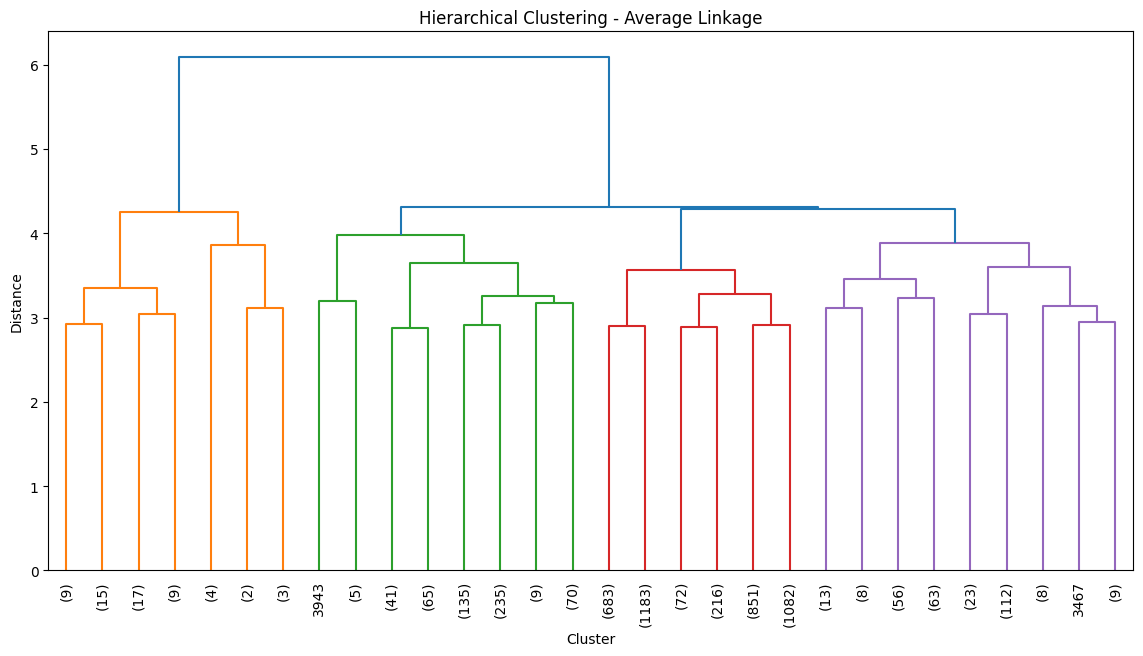

In [79]:
#Average Linkage
linkage_average = linkage(
    X_scaled,
    method='average',
    metric='euclidean'
)
plt.figure(figsize=(14,7))

dendrogram(
    linkage_average,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90
)

plt.title('Hierarchical Clustering - Average Linkage')
plt.xlabel('Cluster')
plt.ylabel('Distance')

plt.show()

In [80]:
#Divide Data into 3 Hierarchical Clusters
from scipy.cluster.hierarchy import fcluster

df['Hierarchical_Cluster'] = fcluster(
    linkage_ward,
    t=3,
    criterion='maxclust'
)

df['Hierarchical_Cluster'].value_counts().sort_index()

,count
Hierarchical_Cluster,
1,1181
2,1409
3,2410


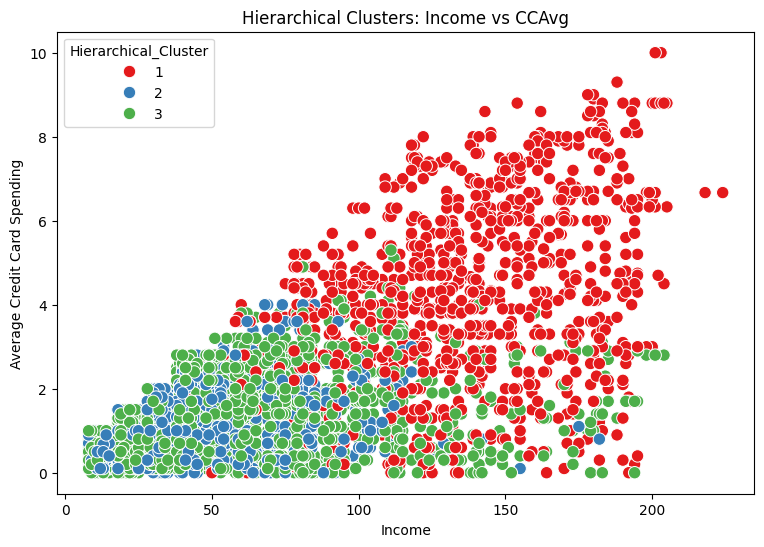

In [81]:
#visualize Hierarchial Clusters
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Income',
    y='CCAvg',
    hue='Hierarchical_Cluster',
    palette='Set1',
    s=80
)

plt.title('Hierarchical Clusters: Income vs CCAvg')
plt.xlabel('Income')
plt.ylabel('Average Credit Card Spending')

plt.show()

In [82]:
#Compare K-means & Hierarchial Clustering
comparison = pd.crosstab(
    df['KMeans_Cluster'],
    df['Hierarchical_Cluster']
)

comparison

Hierarchical_Cluster,1,2,3
KMeans_Cluster,,,
0,770,5,83
1,259,1330,418
2,152,74,1909


Hierarchical clustering was performed using Euclidean distance and different linkage methods, including Single, Complete, Average, and Ward linkage. Dendrograms were generated to visualize the hierarchical relationships between observations. The Ward method was subsequently used to divide the customers into three clusters.